<font color="#99ffcc" size=6><b> Fis 131</b></font>
***

# Import the necessary libraries

- to choose colors for the text and the background: https://www.w3schools.com/colors/colors_picker.asp
- pandas documentatio: https://pandas.pydata.org/pandas-docs/stable/
- sklearn documentation: https://scikit-learn.org/stable/
- Seaborn documentation: https://seaborn.pydata.org/tutorial/introduction

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy.interpolate import interp1d
from scipy.integrate import quad

from pathlib import Path
import os
from datetime import datetime

from matplotlib.animation import FuncAnimation

from IPython.display import display, Math, Latex, Markdown
from sympy import latex
from scipy.optimize import curve_fit
from scipy.stats import linregress
import sympy as sp


from ipywidgets import interact, FloatSlider

import pygame
import random
import math

pygame 2.6.1 (SDL 2.32.68, Python 3.14.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


- Explicación
 - numpy se utiliza para trabajar con arreglos numéricos y funciones matemáticas.
 - matplotlib.pyplot permite generar gráficos.
 - seaborn proporciona paletas de colores y estilos visuales más modernos.

<font color="#99ffcc" size=6><b> 1. Colors to choose </b></font>
***


In [ ]:
colors_blue = ['#e6f0ff', '#cce0ff', '#b3d1ff', '#99c2ff', '#80b3ff', '#66a3ff', '#4d94ff', '#3385ff',  '#1a75ff', '#006ce6',
               "#73af37", '#0052cc', '#0047b3',  '#003d99',  '#003380', '#002966', '#001f4d', '#001433', '#000a1a',] # Light to dark blue 
colors_red = ["#e4ad5a", '#ffd6cc', '#ffc2b3', '#ffad99', '#ff9980', '#ff8566', '#ff704d', '#ff5c33', "#e5866e", '#ff3300','#e62e00',
            '#cc2900', '#b32400',  '#991f00', '#801a00', '#661400', '#4d0f00', '#330a00',] # Light to dark red 
colors_green = ['#e6ffee', '#ccffdd', '#b3ffcc', '#99ffbb', '#80ffaa', '#66ff99', '#4dff88', '#33ff77', '#1aff66', '#00ff55',
                '#00e64d', '#00cc44', '#00b33c',  '#009933', '#00802b', '#006622', '#004d1a','#003311',] # Light to dark green
color_orange =["#cec828", '#ffebcc', '#ffe0b3', '#ffd699', '#ffcc80', '#ffc266', '#ffb84d', '#ffad33', '#ffa31a', '#ff9900',
               '#e68a00', '#cc7a00', "#2c1a00", '#995c00', '#804d00', '#663d00', '#4d2e00', '#331f00', ] # Dark orange
color_purple = ['#f9e6ff', '#f2ccff', '#ecb3ff', '#e699ff', '#df80ff', '#d966ff', '#d24dff', "#a50fd7", '#c61aff',
                '#bf00ff', '#ac00e6', '#9900cc', '#8600b3', '#730099', '#600080', '#4d0066', '#39004d', '#260033',] # Dark purple

<font color="#99ffcc" size=6><b> 1.1 Time stamps for plots and csv files </b></font>
***


In [ ]:
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")

<font color="#ffc2b3" size=7><b> Oscilaciones armónicas y uso de paletas de colores en Python </b></font>
***

- Introducción

En este ejemplo construiremos distintas señales oscilatorias utilizando funciones seno y coseno.
Además, aprenderemos cómo utilizar diferentes paletas de colores con seaborn para representar múltiples curvas de manera clara y visualmente atractiva.

La señal utilizada tendrá la forma:

\begin{equation}
    x(t) = A \cos(w_0 t) + B \sin(w_0 t)
\end{equation}

donde:

  - A y B controlan la amplitud de las componentes coseno y seno.
  - \omega_0  es la frecuencia angular.
  - t representa el tiempo.

La idea será variar el parámetro A y observar cómo cambian las oscilaciones.

In [ ]:
# ---------------------------------------------------------
# PARÁMETROS DEL PROBLEMA
# ---------------------------------------------------------

B = 0.5
# Amplitud de la componente seno

w0 = 2 * np.pi
# Frecuencia angular en radianes por segundo
# Como w0 = 2π, la frecuencia es:
#
# f = w0 / (2π) = 1 Hz
#
# Esto significa que la señal completa
# una oscilación por segundo.

t = np.linspace(0, 2, 500)
# Vector de tiempo desde 0 hasta 2 segundos
# dividido en 500 puntos igualmente espaciados.
#
# np.linspace(inicio, fin, cantidad_puntos)
#
# Esto permite obtener curvas suaves al graficar.

# ---------------------------------------------------------
# VALORES DE A
# ---------------------------------------------------------

A_values = np.arange(0, 1.01, 0.2)

# np.arange(inicio, fin, paso)
#
# Genera valores desde 0 hasta 1
# avanzando en pasos de 0.2.
#
# Se usa 1.01 en lugar de 1.0 para asegurar
# que el valor 1.0 quede incluido.
#
# Resultado:
# [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# ---------------------------------------------------------
# PALETA tab10
# ---------------------------------------------------------

colors_tab10 = sns.color_palette("tab10", len(A_values))

# sns.color_palette devuelve una lista de colores.
#
# "tab10" es una paleta categórica.
#
# len(A_values) = 6
# entonces se generan 6 colores diferentes,
# uno para cada curva.



# Crear figura
plt.figure(figsize=(8, 5))

# zip une ambas listas:
# (A, color)
#
# Ejemplo:
# (0.0, color1)
# (0.2, color2)
# etc.

for A, c in zip(A_values, colors_tab10):

    # Señal oscilatoria:
    x = A * np.cos(w0 * t) + B * np.sin(w0 * t)

    # Graficar la señal
    plt.plot(t, x, color=c, label=f"A = {A:.1f}")

# ---------------------------------------------------------
# CONFIGURACIÓN DEL GRÁFICO
# ---------------------------------------------------------

plt.title("Oscilaciones usando paleta tab10")

plt.xlabel("Tiempo [s]")
plt.ylabel("x(t)")

plt.grid(True)

# Leyenda fuera del gráfico
plt.legend(loc='center left', bbox_to_anchor=(1, 0.84))
plt.tight_layout()

# Guardar imagen en alta resolución
# plt.savefig(f"plot_tab10.png_{timestamp}.png", dpi=300, tight_layout=True)
plt.show()

# ---------------------------------------------------------
# COLORMAP CONTINUO
# ---------------------------------------------------------

spectral = sns.color_palette(
    "Spectral",
    as_cmap=True
)

# as_cmap=True convierte la paleta
# en un colormap continuo.
#
# Ya no tenemos una lista fija de colores,
# sino una función que devuelve colores
# dependiendo de un valor entre 0 y 1.

plt.figure(figsize=(8, 5))

for i, A in enumerate(A_values):

    # Normalización entre 0 y 1
    #
    # Esto permite recorrer todo
    # el colormap de manera uniforme.
    color = spectral(i / (len(A_values) - 1))

    # Señal oscilatoria
    x = A * np.cos(w0 * t) + B * np.sin(w0 * t)

    # Graficar
    plt.plot(t, x, color=color, label=f"A = {A:.1f}")

# ---------------------------------------------------------
# CONFIGURACIÓN FINAL
# ---------------------------------------------------------

plt.title("Oscilaciones usando colormap Spectral")

plt.xlabel("Tiempo [s]")
plt.ylabel("x(t)")

plt.grid(True)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.84)
)

plt.tight_layout()

plt.show()

<font color="#ffc2b3" size=6><b> Comparación entre funciones seno y coseno usando subplots </b></font>
***
- En este ejemplo construiremos dos gráficos lado a lado para comparar funciones oscilatorias de tipo seno y coseno.

La idea es visualizar cómo cambia la amplitud de las señales al variar el parámetro A, utilizando además distintas paletas de colores de seaborn.

 - El gráfico izquierdo mostrará funciones del tipo

\begin{equation}

x(t)=A\cos(\omega_0 t)

\end{equation}

 - El gráfico derecho mostrará funciones del tipo:

\begin{equation}

x(t)=A\sin(\omega_0 t)

\end{equation}

Utilizaremos:

una paleta categórica (tab10)
y un colormap continuo (Spectral)

para aprender distintas formas de representar múltiples curvas.

In [ ]:
# Parámetros de la señal
B = 0.5                      # Amplitud del término seno
w0 = 2*np.pi                 # Frecuencia angular (2π rad/s → 1 Hz)
t = np.linspace(0, 2, 500)   # Vector de tiempo de 0 a 2 segundos con 500 puntos

# Valores de A
A_values = np.arange(0, 1.01, 0.2)  
# np.arange genera valores desde 0 hasta 1 (incluyendo 1.0 porque puse 1.01) en pasos de 0.2
# Resultado: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Crear figura con 2 subplots en una fila (1x2)
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
# axs es un array con dos ejes: axs[0] a la izquierda, axs[1] a la derecha
# sharey=True hace que ambos compartan el mismo eje Y para comparación directa

# --- Primer subplot con paleta tab10 ---
colors_tab10 = sns.color_palette("tab10", len(A_values))
# sns.color_palette devuelve una lista de colores.
# "tab10" es una paleta categórica con 10 colores distintos.
# len(A_values) = 6, entonces se generan 6 colores para las 6 curvas.

for A, c in zip(A_values, colors_tab10):
    # zip combina dos listas en pares: (A, color)
    # Ejemplo: (0.0, primer color), (0.2, segundo color), etc.
    x = A * np.cos(w0 * t) # + B * np.sin(w0 * t)  # Señal para ese A
    axs[0].plot(t, x, color=c, label=f"A={A:.1f}")  # Graficar con su color y etiqueta

axs[0].set_title(r"Usando paleta tab10 $A\cos\omega_0 t$")
axs[0].set_xlabel("Tiempo [s]", loc='right')
axs[0].set_ylabel("x(t)", loc='top')
axs[0].grid(True)
axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.845))  # Leyenda a la derecha del subplot

# --- Segundo subplot con paleta Spectral ---
spectral = sns.color_palette("Spectral", as_cmap=True)
# Aquí "Spectral" es una paleta continua (colormap).
# as_cmap=True devuelve un objeto tipo colormap, no una lista fija de colores.

for i, A in enumerate(A_values):
    color = spectral(i / (len(A_values)-1))  
    # Se normaliza el índice i entre 0 y 1 dividiendo por (len(A_values)-1).
    # Así se recorre el colormap de manera uniforme para cada curva.
    x =  A * np.sin(w0 * t) # A * np.cos(w0 * t) 
    axs[1].plot(t, x, color=color, label=f"A={A:.1f}")

axs[1].set_title(r"Usando paleta Spectral (cmap) $B\sin\omega_0 t$")
axs[1].set_xlabel(r"Tiempo [s]", loc='right')
axs[1].set_ylabel("x(t)", loc='top')
axs[1].grid(True)
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.845))

# Ajustar diseño para que no se solapen títulos/etiquetas
plt.tight_layout()

# Guardar ambos subplots en un solo archivo PNG con timestamp
plt.subplots_adjust(wspace=0.35)  # aumenta separación horizontal
plt.savefig(f"plots_side_by_side_{timestamp}.png", dpi=300, bbox_inches="tight")
plt.show()


<font color="#ffc2b3" size=6><b> Superposición de oscilaciones: seno, coseno y su suma </b></font>
***

En este ejemplo estudiaremos cómo se combinan dos funciones oscilatorias básicas:

\begin{equation}
    Acos(\omega_0	​t)
\end{equation}

y
\begin{equation}
    Bsin(\omega_0 t)
\end{equation}

para formar una nueva señal:

\begin{equation}
  x(t)=Acos(\omega_0 t) + Bsin(\omega_0 t)
\end{equation}

Este tipo de combinación aparece constantemente en:

  - oscilaciones mecánicas,
  - ondas,
  - circuitos eléctricos,
  - procesamiento de señales,
  - y física en general.

La idea del notebook es visualizar:

  - la componente coseno,
  - la componente seno,
  - y finalmente la señal resultante de sumar ambas.

In [ ]:
# =========================================================
# PARÁMETROS DE LA SEÑAL
# =========================================================

A = 1.0
# Amplitud de la componente coseno

B = 1.0
# Amplitud de la componente seno

w_0 = 2 * np.pi
# Frecuencia angular:
#
# ω0 = 2π rad/s
#
# Esto corresponde a:
#
# f = ω0 / (2π) = 1 Hz
#
# La señal completa una oscilación
# por segundo.


# =========================================================
# VECTOR DE TIEMPO
# =========================================================

t = np.linspace(0, 2, 500)

# np.linspace(inicio, fin, cantidad_puntos)
#
# Genera 500 puntos igualmente espaciados
# entre 0 y 2 segundos.
#
# Esto permite obtener gráficos suaves.
# =========================================================
# FUNCIONES OSCILATORIAS
# =========================================================

coseno = A * np.cos(w_0 * t)

# Señal:
#
# A cos(ω0 t)


seno = B * np.sin(w_0 * t)

# Señal:
#
# B sin(ω0 t)


# =========================================================
# SUPERPOSICIÓN DE ONDAS
# =========================================================

suma = coseno + seno

# La señal final corresponde
# a la suma punto a punto
# de ambas oscilaciones.
#
# Esto representa el principio
# de superposición de ondas.
# =========================================================
# CREAR FIGURA Y SUBPLOTS
# =========================================================

fig, axs = plt.subplots(
    3,              # 3 filas
    1,              # 1 columna
    figsize=(8, 6),
    sharex=True     # Compartir eje X
)

# axs[0] → coseno
# axs[1] → seno
# axs[2] → suma
# =========================================================
# GRÁFICO DEL COSENO
# =========================================================

axs[0].plot(t, coseno, 'r' )

# 'r' indica color rojo
axs[0].set_title(r'$A\cos(\omega_0 t)$')
axs[0].set_xlabel('Tiempo [s]', loc='right')
axs[0].set_ylabel('Amplitud',  loc='top' )
axs[0].grid(True)
# =========================================================
# GRÁFICO DEL SENO
# =========================================================

axs[1].plot(t, seno, 'b')
# 'b' indica color azul
axs[1].set_title(r'$B\sin(\omega_0 t)$')
axs[1].set_xlabel('Tiempo [s]', loc='right')
axs[1].set_ylabel('Amplitud', loc='top' )
axs[1].grid(True)
# =========================================================
# GRÁFICO DE LA SUPERPOSICIÓN
# =========================================================

axs[2].plot(t, suma, 'g')
# 'g' indica color verde
axs[2].set_title(r'$A\cos(\omega_0 t)+B\sin(\omega_0 t)$')
axs[2].set_xlabel('Tiempo [s]', loc='right' )
axs[2].set_ylabel('Amplitud', loc='top')
axs[2].grid(True)

# =========================================================
# AJUSTES FINALES
# =========================================================

# Separación vertical entre subplots
plt.subplots_adjust(hspace=0.5)
# Guardar imagen en alta resolución
plt.savefig(f"suma_de_ondas_{timestamp}.png", dpi=300)

# Mostrar figura
plt.show()

Interpretación física

La suma de funciones seno y coseno produce otra oscilación periódica.

De hecho, matemáticamente puede demostrarse que:

\begin{equation}
    Acos(\omega_0 t)+Bsin(\omega_0 t)
\end{equation}

puede escribirse como una única oscilación:

\begin{equation}
    C \cos(\omega_0 t−\phi)
\end{equation}
donde:

  - C es la nueva amplitud,
  - $\phi$ es un desfase.

Esto es extremadamente importante en física y en teoría de ondas, ya que muchas oscilaciones complejas pueden entenderse como combinaciones de señales simples.

<font color="#d24dff" size=7><b> Oscilador amortiguado </b></font>
***
En este ejemplo estudiaremos una oscilación cuya amplitud disminuye con el tiempo debido a un efecto de amortiguamiento, como ocurre en sistemas con roce, fricción o resistencia del aire.

La solución tiene la forma:

\begin{equation}
    x(t) = A_0 ​e^{−\gamma t}\cos(\Omega^{'}t + \phi)
\end{equation}

donde:

  - $A_0$: es la amplitud inicial,
  - $\gamma$: es el coeficiente de amortiguamiento,
  - $\Omega^{'}$ es la frecuencia angular amortiguada,
  - $\phi$: es la fase inicial.

La función exponencial:
    $$A_0e^{-\gamma t}$$

actúa como una envolvente, es decir, limita el tamaño máximo de la oscilación a medida que pasa el tiempo.

In [ ]:
# =========================================================
# PARÁMETROS DEL OSCILADOR AMORTIGUADO
# =========================================================

A0 = 1.0
# Amplitud inicial.
# Corresponde al valor máximo inicial de la oscilación.

gamma = 0.3
# Coeficiente de amortiguamiento.
# Mientras mayor sea gamma, más rápido disminuye la amplitud.

Omega_p = 2 * np.pi
# Frecuencia angular amortiguada.
#
# Omega_p = 2π rad/s
#
# Esto corresponde aproximadamente a una oscilación por segundo.

phi = 0.0
# Fase inicial.
# Controla el punto de partida de la oscilación.

t = np.linspace(0, 10, 1000)
# Vector de tiempo desde 0 hasta 10 segundos
# usando 1000 puntos igualmente espaciados.
# Esto permite obtener una curva suave.


# =========================================================
# ENVOLVENTES EXPONENCIALES
# =========================================================

envolvente_sup = A0 * np.exp(-gamma * t)
# Envolvente superior:
#
# +A0 e^(-gamma t)
#
# Marca el límite superior de la oscilación.

envolvente_inf = -A0 * np.exp(-gamma * t)
# Envolvente inferior:
#
# -A0 e^(-gamma t)
#
# Marca el límite inferior de la oscilación.


# =========================================================
# OSCILACIÓN SIN AMORTIGUAMIENTO
# =========================================================

sin_amortiguamiento = A0 * np.cos(Omega_p * t + phi)

# Caso ideal sin pérdida de energía:
#
# x(t) = A0 cos(Omega' t + phi)
#
# En este caso la amplitud permanece constante.


# =========================================================
# OSCILACIÓN AMORTIGUADA
# =========================================================

solucion_amortiguada = (
    A0
    * np.exp(-gamma * t)
    * np.cos(Omega_p * t + phi)
)

# Solución amortiguada:
#
# x(t) = A0 e^(-gamma t) cos(Omega' t + phi)
#
# La parte cosenoidal genera la oscilación,
# mientras que la exponencial reduce la amplitud
# a medida que avanza el tiempo.

# =========================================================
# GRÁFICO
# =========================================================

plt.figure(figsize=(10, 6))

# ---------------------------------------------------------
# Oscilación sin amortiguamiento
# ---------------------------------------------------------

plt.plot(t, sin_amortiguamiento, 'b--', label=r"$\gamma=0$: $A_0\cos(\Omega' t+\phi)$")
# Línea azul discontinua:
# representa el caso ideal sin pérdida de energía.


# ---------------------------------------------------------
# Envolvente superior
# ---------------------------------------------------------

plt.plot(t, envolvente_sup, 'r--', label=r"$A_0 e^{-\gamma t}$")
# Línea roja discontinua superior.

# ---------------------------------------------------------
# Envolvente inferior
# ---------------------------------------------------------

plt.plot(t, envolvente_inf, 'r--', label=r"$-A_0 e^{-\gamma t}$")
# Línea roja discontinua inferior.


# ---------------------------------------------------------
# Solución amortiguada
# ---------------------------------------------------------

plt.plot(t, solucion_amortiguada, 'g-', linewidth=2, label=r"$A_0 e^{-\gamma t}\cos(\Omega' t+\phi)$" )

# Línea verde continua:
# representa la oscilación real amortiguada.


# =========================================================
# DECORACIÓN DEL GRÁFICO
# =========================================================

plt.title("Oscilador amortiguado")
plt.xlabel("Tiempo [s]", loc='right' )
plt.ylabel("x(t)", loc='top' )
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.887) )
plt.tight_layout()

plt.savefig(f"Oscilador_amortiguado_{timestamp}.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretación física

En ausencia de amortiguamiento, la oscilación mantiene siempre la misma amplitud y el sistema conserva su energía mecánica.

Sin embargo, cuando existe amortiguamiento $(\gamma > 0)$, la amplitud disminuye progresivamente debido a pérdidas de energía causadas por efectos disipativos como:

- roce,
- fricción,
- resistencia del aire,
- o disipación eléctrica.

La solución amortiguada:

\begin{equation}
    x(t)=A_0 e^{-\gamma t}\cos(\Omega' t+\phi)
\end{equation}

puede interpretarse como una oscilación cosenoidal cuya amplitud ya no es constante, sino que está controlada por la función exponencial:

\begin{equation}
    A_0 e^{-\gamma t}
\end{equation}

Esta función actúa como una envolvente que limita el valor máximo y mínimo de la oscilación:

\begin{equation}
    -A_0 e^{-\gamma t}
    \leq
    x(t)
    \leq
    A_0 e^{-\gamma t}
\end{equation}

A medida que el tiempo aumenta, la envolvente decrece exponencialmente y la oscilación se atenúa gradualmente hasta desaparecer.

Este comportamiento aparece en numerosos sistemas físicos reales, por ejemplo:

- péndulos con fricción,
- resortes amortiguados,
- circuitos RLC,
- vibraciones mecánicas,
- y propagación de ondas en medios disipativos.

In [ ]:
# Timestamp para guardar archivo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Parámetros fijos
A0 = 1.0          # Amplitud inicial
Omega_p = 2*np.pi # Frecuencia angular amortiguada
phi = 0.0         # Fase inicial
t = np.linspace(0, 1.5, 1000)  # Tiempo de 0 a 1.5 segundos

# Valores de gamma a comparar
gamma_values = [0.0, 5, 10, 20]

plt.figure(figsize=(10, 6))

for gamma in gamma_values:
    # Solución completa: A0 * exp(-gamma t) * cos(Omega' t + phi)
    x = A0 * np.exp(-gamma * t) * np.cos(Omega_p * t + phi)
    plt.plot(t, x, label=fr'$\gamma={gamma}$')

# --- Calcular automáticamente el primer cero del coseno ---
t_zero = (np.pi/2 - phi) / Omega_p   # primer cruce positivo
plt.axvline(x=t_zero, color='k', linestyle=':', linewidth=2,
            label=fr'$t = {t_zero:.2f}\,\text{{s}}$')

# --- Decoración del gráfico ---
plt.title(r"Oscilador amortiguado para distintos valores de $\gamma$, "
          r"$x(t) = A_0 e^{-\gamma t}\cos(\Omega' t + \phi)$")
plt.xlabel("Tiempo [s]", loc='right')
plt.ylabel("x(t)", loc='top')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.882))
plt.tight_layout()
plt.savefig(f"Oscilador_amortiguado_gammadistintos_concero_{timestamp}.png", dpi=300, bbox_inches="tight")
plt.show()


<font color="#d24dff" size=7><b> Oscilador armónico forzado amortiguado </b></font>
***

En este ejemplo estudiaremos un sistema oscilatorio sometido simultáneamente a:

- una fuerza restauradora,
- un amortiguamiento,
- y una fuerza externa periódica.

La ecuación diferencial del sistema es:

\begin{equation}
    \ddot{x}
    +
    2\gamma \dot{x}
    +
    \omega_0^2 x
    =
    A\cos(\omega t)
\end{equation}

donde:

- $\omega_0$: frecuencia natural del sistema,
- $\gamma$: coeficiente de amortiguamiento,
- $\omega$: frecuencia angular de la fuerza externa,
- $A$: amplitud de la fuerza externa.

Este sistema es uno de los modelos más importantes de la física, ya que describe fenómenos como:

- circuitos RLC,
- vibraciones mecánicas,
- resonancia,
- ondas forzadas,
- oscilaciones en estructuras,
- y sistemas acoplados.

---

## Estructura de la solución

La solución total del sistema puede separarse en dos contribuciones:

\begin{equation}
    x(t)=x_h(t)+x_p(t)
\end{equation}

donde:

- $x_h(t)$ corresponde a la solución homogénea o transitoria,
- $x_p(t)$ corresponde a la solución particular o estacionaria.

---

## Parte homogénea: régimen transitorio

La parte homogénea describe el comportamiento natural del sistema cuando no existe fuerza externa.

Para el caso subamortiguado $(\omega_0 > \gamma)$, la solución es:

\begin{equation}
    x_h(t)
    =
    e^{-\gamma t}
    \left[
        C_1\cos(\Omega t)
        +
        C_2\sin(\Omega t)
    \right]
\end{equation}

donde:

\begin{equation}
    \Omega
    =
    \sqrt{\omega_0^2-\gamma^2}
\end{equation}

es la frecuencia angular amortiguada.

La exponencial:

\begin{equation}
    e^{-\gamma t}
\end{equation}

provoca que esta parte desaparezca progresivamente con el tiempo.

Por esta razón, la solución homogénea se conoce como:

- solución transitoria,
- régimen transitorio,
- o respuesta natural del sistema.

---

## Parte particular: régimen estacionario

La solución particular representa la respuesta forzada producida por la fuerza externa periódica.

Tiene la forma:

\begin{equation}
    x_p(t)
    =
    a\cos(\omega t)
    +
    b\sin(\omega t)
\end{equation}

donde los coeficientes:

\begin{equation}
    a=
    \frac{
        A(\omega_0^2-\omega^2)
    }{
        (\omega_0^2-\omega^2)^2
        +
        4\gamma^2\omega^2
    }
\end{equation}

y

\begin{equation}
    b=
    \frac{
        2\gamma\omega A
    }{
        (\omega_0^2-\omega^2)^2
        +
        4\gamma^2\omega^2
    }
\end{equation}

dependen de:

- la frecuencia natural,
- la frecuencia externa,
- y el amortiguamiento.

La solución particular permanece incluso cuando el tiempo es muy grande.

Por eso se denomina:

- solución estacionaria,
- régimen permanente,
- o respuesta forzada.



In [ ]:
# =========================================================
# PARÁMETROS FÍSICOS DEL SISTEMA
# =========================================================

omega_0 = 2.0
# Frecuencia natural del oscilador

gamma = 0.25
# Coeficiente de amortiguamiento

omega = 1.8
# Frecuencia angular de la fuerza externa

A = 1.0
# Amplitud de la fuerza externa dividida por la masa


# =========================================================
# CONDICIONES INICIALES
# =========================================================

C1 = 1.0
C2 = 0.0

# Estas constantes determinan
# la solución homogénea inicial.


# =========================================================
# VECTOR DE TIEMPO
# =========================================================

t = np.linspace(0, 30, 2000)

# Intervalo temporal:
#
# desde 0 hasta 30 segundos
# usando 2000 puntos.


# =========================================================
# FRECUENCIA AMORTIGUADA
# =========================================================

if omega_0 > gamma:

    Omega = np.sqrt(
        omega_0**2 - gamma**2
    )

else:

    raise ValueError(
        "Este código usa el caso subamortiguado: omega_0 > gamma"
    )

# Ω representa la frecuencia angular
# del movimiento amortiguado.


# =========================================================
# PARTE HOMOGÉNEA (TRANSITORIA)
# =========================================================

x_h = (
    np.exp(-gamma * t)
    *
    (
        C1 * np.cos(Omega * t)
        +
        C2 * np.sin(Omega * t)
    )
)

# Solución homogénea:
#
# x_h(t)=e^(-γt)[C1 cos(Ωt)+C2 sin(Ωt)]
#
# Representa la respuesta natural del sistema.
#
# La exponencial hace que esta parte
# desaparezca gradualmente.


# =========================================================
# PARTE PARTICULAR (ESTACIONARIA)
# =========================================================

den = (
    (omega_0**2 - omega**2)**2
    +
    4 * gamma**2 * omega**2
)

# Denominador común
# de los coeficientes.


a = (
    A * (omega_0**2 - omega**2)
    / den
)

b = (
    2 * gamma * omega * A
    / den
)

# Coeficientes de la solución particular.


x_p = (
    a * np.cos(omega * t)
    +
    b * np.sin(omega * t)
)

# Solución particular:
#
# x_p(t)=a cos(ωt)+b sin(ωt)
#
# Representa la respuesta forzada
# producida por la fuerza externa.


# =========================================================
# SOLUCIÓN TOTAL
# =========================================================

x = x_h + x_p

# La solución completa es:
#
# x(t)=x_h(t)+x_p(t)


# =========================================================
# GRÁFICO
# =========================================================

plt.figure(figsize=(10, 6))


# ---------------------------------------------------------
# Parte transitoria
# ---------------------------------------------------------

plt.plot(
    t,
    x_h,
    linestyle='--',
    label='Parte transitoria $x_h(t)$'
)


# ---------------------------------------------------------
# Parte estacionaria
# ---------------------------------------------------------

plt.plot(
    t,
    x_p,
    linestyle=':',
    label='Parte estacionaria $x_p(t)$'
)


# ---------------------------------------------------------
# Solución total
# ---------------------------------------------------------

plt.plot(
    t,
    x,
    linewidth=2,
    label='Solución total $x(t)$'
)


# =========================================================
# DECORACIÓN DEL GRÁFICO
# =========================================================

plt.xlabel('Tiempo $t$')

plt.ylabel('$x(t)$')

plt.title(
    'Oscilador armónico forzado amortiguado'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

---

## Interpretación física

Al inicio del movimiento, el sistema contiene simultáneamente:

- una oscilación natural propia,
- y la respuesta producida por la fuerza externa.

Sin embargo, debido al amortiguamiento, la parte transitoria:

\begin{equation}
    x_h(t)
\end{equation}

desaparece gradualmente.

Después de un tiempo suficientemente grande:

\begin{equation}
    x(t)\approx x_p(t)
\end{equation}

y el sistema oscila únicamente con la frecuencia de la fuerza externa.

Este fenómeno es extremadamente importante en física e ingeniería, especialmente en:

- resonancia mecánica,
- vibraciones estructurales,
- circuitos eléctricos,
- acústica,
- y sistemas dinámicos.

Cuando la frecuencia externa $\omega$ se aproxima a la frecuencia natural $\omega_0$, la amplitud de la respuesta puede aumentar considerablemente, produciendo el fenómeno de resonancia.

<font color="#cec828" size=7><b> Termodinamica</b></font> 
***

# Procesos termodinámicos entre dos isotermas

En este ejemplo estudiaremos distintos caminos termodinámicos que conectan dos isotermas de un gas ideal.

Utilizaremos la ecuación de estado del gas ideal:

\begin{equation}
    PV=nRT
\end{equation}

donde:

- $P$: presión,
- $V$: volumen,
- $n$: número de moles,
- $R$: constante universal de los gases,
- $T$: temperatura absoluta.

---

## Isotermas

Una isoterma corresponde a un conjunto de estados del sistema con temperatura constante.

Para un gas ideal:

\begin{equation}
    P(V)=\frac{nRT}{V}
\end{equation}

Por esta razón:

- temperaturas mayores producen isotermas más altas,
- y temperaturas menores generan isotermas más bajas.

En este notebook compararemos dos isotermas:

\begin{equation}
    T_1=300\ K
\end{equation}

y

\begin{equation}
    T_2=450\ K
\end{equation}

---

## Procesos considerados

Analizaremos dos procesos diferentes para pasar desde la isoterma inicial hasta la final.

### Proceso isocórico (volumen constante)

En un proceso isocórico:

\begin{equation}
    \Delta V=0
\end{equation}

El volumen permanece fijo y únicamente cambia la presión.

El calor transferido es:

\begin{equation}
    Q=nC_V\Delta T
\end{equation}

donde $C_V$ es el calor específico molar a volumen constante.

En el diagrama $P-V$ este proceso aparece como una línea vertical.

---

### Proceso isobárico (presión constante)

En un proceso isobárico:

\begin{equation}
    \Delta P=0
\end{equation}

La presión permanece constante mientras cambia el volumen.

El calor transferido es:

\begin{equation}
    Q=nC_P\Delta T
\end{equation}

donde $C_P$ es el calor específico molar a presión constante.

En el diagrama $P-V$ este proceso aparece como una línea horizontal.

---

## Interpretación física

Aunque ambos procesos conectan las mismas isotermas y experimentan la misma variación de temperatura:

\begin{equation}
    \Delta T=T_2-T_1
\end{equation}

la cantidad de calor transferido no es la misma.

Esto ocurre porque:

- en el proceso isocórico el sistema no realiza trabajo,
- mientras que en el proceso isobárico el sistema se expande y realiza trabajo sobre el entorno.

Por esta razón:

\begin{equation}
    C_P > C_V
\end{equation}

ya que en el caso isobárico parte del calor suministrado se utiliza para realizar trabajo mecánico.

El gráfico permite visualizar cómo distintos caminos termodinámicos pueden conectar los mismos estados iniciales y finales, pero involucrando diferentes intercambios de energía.

In [ ]:
# =========================================================
# CONSTANTES FÍSICAS
# =========================================================
# Constante universal de los gases
# [J/(mol·K)]
R = 8.314

# Número de moles
n = 1



# =========================================================
# TEMPERATURAS
# =========================================================

# Temperatura inicial [K]
T1 = 250

# Temperatura final [K]
T2 = 730


# =========================================================
# VECTOR DE VOLÚMENES
# =========================================================

# Volúmenes entre 1 y 6
# usando 400 puntos.

V = np.linspace(1, 6, 2000)

# =========================================================
# ISOTERMAS DEL GAS IDEAL
# =========================================================

# Se usa:
#--------
# P = nRT / V

P1 = n * R * T1 / V
# Isoterma correspondiente a T1

P2 = n * R * T2 / V
# Isoterma correspondiente a T2

# =========================================================
# ESTADO INICIAL
# =========================================================

Vi = 2.0
# Volumen inicial

Pi = n * R * T1 / Vi
# Presión inicial


# =========================================================
# PROCESO ISOCÓRICO
# =========================================================

# El volumen permanece constante
Vf_constV = Vi

# Nueva presión sobre la segunda isoterma
Pf_constV = n * R * T2 / Vf_constV
# =========================================================
# PROCESO ISOBÁRICO
# =========================================================

Pf_constP = Pi
# La presión permanece constante

Vf_constP = n * R * T2 / Pf_constP
# Nuevo volumen sobre la segunda isoterma


# =========================================================
# CREAR FIGURA
# =========================================================

plt.figure(figsize=(8, 6))


# =========================================================
# GRAFICAR ISOTERMAS
# =========================================================

plt.plot(V, P1, label=r'Isoterma $T$')
plt.plot(V, P2, label=r'Isoterma $T+\Delta T$' )


# =========================================================
# PROCESO ISOCÓRICO
# =========================================================

# Línea vertical:
# volumen fijo.
plt.plot([Vi, Vf_constV], [Pi, Pf_constV], linestyle='--', linewidth=2, label=r'$i \to f$ volumen constante' )

# =========================================================
# PROCESO ISOBÁRICO
# =========================================================

# Línea horizontal:
# presión fija.
plt.plot([Vi, Vf_constP], [Pi, Pf_constP], linestyle='-.', linewidth=2, label=r"$f^{\,\, '} \to i$ presión constante" )


# =========================================================
# PUNTOS IMPORTANTES
# =========================================================

# Estado inicial y estados finales.
plt.scatter([Vi, Vf_constV, Vf_constP+0.15], [Pi, Pf_constV, Pf_constP] )

# =========================================================
# ETIQUETAS DE LOS PUNTOS
# =========================================================

plt.text(Vi - 0.15, Pi - 150, r'$i$', fontsize=14)
plt.text(Vf_constV + 0.1, Pf_constV, r'$f$', fontsize=14 )
plt.text(Vf_constP + 0.1, Pf_constP+100.5, r"$f^{\,\, '}$", fontsize=14)


# =========================================================
# TEXTO EXPLICATIVO EN EL GRÁFICO
# =========================================================

plt.text(2.7, 1600, r"(isocórico) $Q = n C_V \Delta T$", ha='center', fontsize=12, color='green')
plt.text(3.1, 1077, r"(isobárico) $Q = n C_P \Delta T$", ha='center', fontsize=12, color='red')


# =========================================================
# DECORACIÓN DEL GRÁFICO
# =========================================================

plt.xlabel(r'Volumen $V$', fontsize=14, loc='right')
plt.ylabel(r'Presión $P$', fontsize=14,loc='top')

plt.title('Procesos entre dos isotermas')
plt.legend()
plt.grid(True)
plt.tight_layout()


# =========================================================
# GUARDAR FIGURA
# =========================================================

plt.savefig(f"isotermas_Cv_Cp_{timestamp}.png", dpi=300, bbox_inches="tight" )

plt.show()

In [ ]:
# =========================================================
# DATOS DEL PROBLEMA
# =========================================================

P1 = 100e3   # Presión baja [Pa]
P2 = 300e3   # Presión alta [Pa]

V1 = 0.010   # Volumen inicial [m^3]
V2 = 0.020   # Volumen después de la expansión isobárica [m^3]

# Como C -> D es isotérmico:
# P2 V2 = P1 V3
V3 = P2 * V2 / P1

# =========================================================
# ESTADOS DEL CICLO
# =========================================================

A = (V1, P1)
B = (V1, P2)
C = (V2, P2)
D = (V3, P1)

# =========================================================
# CÁLCULO DEL TRABAJO
# =========================================================

# =========================================================
# TRABAJO EN CADA TRAMO
# =========================================================

display(Markdown("# Trabajo realizado por el gas"))

W_AB = 0

W_BC = P2 * (V2 - V1)

W_CD = P2 * V2 * np.log(V3 / V2)

W_DA = P1 * (V1 - V3)

W_net = W_AB + W_BC + W_CD + W_DA

display(Math(r"\textbf{Tramo }A\rightarrow B\ (\mathrm{isocórico})"))
display(Math(r"W_{AB}=0"))
display(Math(rf"W_{{AB}}={W_AB:.2f}\,\mathrm{{J}}"))

display(Math(r"\textbf{Tramo }B\rightarrow C\ (\mathrm{isobárico})"))
display(Math(rf"W_{{BC}}=P_2(V_2-V_1)=({P2:.0f})({V2:.3f}-{V1:.3f})"))
display(Math(rf"W_{{BC}}={W_BC:.2f}\,\mathrm{{J}}"))

display(Math(r"\textbf{Tramo }C\rightarrow D\ (\mathrm{isotérmico})"))
display(Math(
r"W_{CD}=P_2V_2\ln\left(\frac{V_3}{V_2}\right)"
))
display(Math(rf"W_{{CD}}={W_CD:.2f}\,\mathrm{{J}}"))

display(Math(r"\textbf{Tramo }D\rightarrow A\ (\mathrm{isobárico})"))
display(Math(rf"W_{{DA}}=P_1(V_1-V_3)"))
display(Math(rf"W_{{DA}}={W_DA:.2f}\,\mathrm{{J}}"))

display(Math(rf"\boxed{{W_{{\rm neto}}={W_net:.2f}\,\mathrm{{J}}}}"))
# =========================================================
# ENERGÍA INTERNA
# =========================================================

display(Markdown("# Variación de energía interna"))

display(Math(r"\Delta U=\frac{3}{2}\Delta(PV)"))

def delta_U(P_i, V_i, P_f, V_f):
    return (3/2)*(P_f*V_f - P_i*V_i)

dU_AB = delta_U(P1, V1, P2, V1)
dU_BC = delta_U(P2, V1, P2, V2)
dU_CD = delta_U(P2, V2, P1, V3)
dU_DA = delta_U(P1, V3, P1, V1)

display(Math(rf"\Delta U_{{AB}}={dU_AB:.2f}\,\mathrm{{J}}"))
display(Math(rf"\Delta U_{{BC}}={dU_BC:.2f}\,\mathrm{{J}}"))
display(Math(rf"\Delta U_{{CD}}={dU_CD:.2f}\,\mathrm{{J}}"))
display(Math(rf"\Delta U_{{DA}}={dU_DA:.2f}\,\mathrm{{J}}"))

dU_cycle = dU_AB + dU_BC + dU_CD + dU_DA

display(Math(rf"\boxed{{\Delta U_{{\rm ciclo}}={dU_cycle:.2e}\,\mathrm{{J}}}}"))

# =========================================================
# CALOR EN CADA TRAMO
# =========================================================

display(Markdown("# Aplicación de la primera ley"))
display(Math(r"Q=\Delta U + W"))

Q_AB = dU_AB + W_AB
Q_BC = dU_BC + W_BC
Q_CD = dU_CD + W_CD
Q_DA = dU_DA + W_DA

# ------------------------
# A -> B
# ------------------------

display(Math(r"\textbf{Tramo }A\rightarrow B"))

display(Math(rf"Q_{{AB}}=\Delta U_{{AB}}+W_{{AB}}"))
display(Math(rf"Q_{{AB}}={dU_AB:.2f}+{W_AB:.2f}"))
display(Math(rf"\boxed{{Q_{{AB}}={Q_AB:.2f}\,\mathrm{{J}}}}"))

# ------------------------
# B -> C
# ------------------------

display(Math(r"\textbf{Tramo }B\rightarrow C"))
display(Math(rf"Q_{{BC}}={dU_BC:.2f}+{W_BC:.2f}"))
display(Math(rf"\boxed{{Q_{{BC}}={Q_BC:.2f}\,\mathrm{{J}}}}"))

# ------------------------
# C -> D
# ------------------------

display(Math(r"\textbf{Tramo }C\rightarrow D"))
display(Math(r"\Delta U_{CD}=0"))
display(Math(rf"Q_{{CD}}={dU_CD:.2f}+{W_CD:.2f}"))
display(Math(rf"\boxed{{Q_{{CD}}={Q_CD:.2f}\,\mathrm{{J}}}}"))

# ------------------------
# D -> A
# ------------------------

display(Math(r"\textbf{Tramo }D\rightarrow A"))

display(Math(rf"Q_{{DA}}={dU_DA:.2f}+{W_DA:.2f}"))

display(Math(rf"\boxed{{Q_{{DA}}={Q_DA:.2f}\,\mathrm{{J}}}}"))


# =========================================================
# CURVAS PARA GRAFICAR
# =========================================================

# Tramo A -> B: volumen constante
V_AB = np.array([V1, V1])
P_AB = np.array([P1, P2])

# Tramo B -> C: presión constante
V_BC = np.array([V1, V2])
P_BC = np.array([P2, P2])

# Tramo C -> D: isoterma
V_CD = np.linspace(V2, V3, 300)
P_CD = P2 * V2 / V_CD

# Tramo D -> A: presión constante
V_DA = np.array([V3, V1])
P_DA = np.array([P1, P1])

# =========================================================
# GRÁFICO P-V
# =========================================================

plt.figure(figsize=(8, 6))

plt.plot(V_AB, P_AB / 1000, linewidth=2, label=r"$A\to B$ isocórico")
plt.plot(V_BC, P_BC / 1000, linewidth=2, label=r"$B\to C$ isobárico")
plt.plot(V_CD, P_CD / 1000, linewidth=2, label=r"$C\to D$ isotérmico")
plt.plot(V_DA, P_DA / 1000, linewidth=2, label=r"$D\to A$ isobárico")

# Puntos del ciclo
for name, (V, P) in zip(["A", "B", "C", "D"], [A, B, C, D]):
    plt.scatter(V, P / 1000, s=60)
    plt.text(V * 1.02, P / 1000, name, fontsize=14)

# Rellenar área aproximada del ciclo
V_fill = np.concatenate([V_BC, V_CD, V_DA])
P_fill = np.concatenate([P_BC, P_CD, P_DA])

plt.fill(V_fill, P_fill / 1000, alpha=0.15)



# =========================================================
# FLECHAS DE DIRECCIÓN DEL CICLO
# =========================================================

# The arrows are created using:
#
# plt.annotate(
#     '',
#     xy=(x_final, y_final),
#     xytext=(x_initial, y_initial),
#     arrowprops=dict(arrowstyle='->')
# )
#
# where:
#
# xy      = tip of the arrow
# xytext  = starting point of the arrow
#
# Therefore:
#
# the arrow points from xytext toward xy.


# ---------------------------------------------------------
# Arrow for A -> B (isochoric process)
# ---------------------------------------------------------

# Since A -> B is a vertical line,
# we manually choose two pressure values
# along that segment.

P_arrow_start = P1 + 0.25 * (P2 - P1)
P_arrow_end   = P1 + 0.45 * (P2 - P1)

plt.annotate(
    '',
    xy=(
        V1,
        P_arrow_end / 1000
    ),
    xytext=(
        V1,
        P_arrow_start / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# This arrow points upward,
# representing the direction A -> B.


# ---------------------------------------------------------
# Arrow for B -> C (isobaric expansion)
# ---------------------------------------------------------

# V_BC contains only two points:
#
# [V1, V2]
#
# so we manually choose intermediate positions.

V_arrow_start = V1 + 0.30 * (V2 - V1)
V_arrow_end   = V1 + 0.55 * (V2 - V1)

plt.annotate(
    '',
    xy=(
        V_arrow_end,
        P2 / 1000
    ),
    xytext=(
        V_arrow_start,
        P2 / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# This arrow points to the right,
# representing the expansion B -> C.


# ---------------------------------------------------------
# Arrow for C -> D (isothermal expansion)
# ---------------------------------------------------------

# The isothermal curve was generated with 300 points:
#
# V_CD = np.linspace(V2, V3, 300)
#
# Therefore:
#
# V_CD[0]     = first point
# V_CD[299]   = last point
#
# i = 120 means:
#
# "use the point number 120 of the curve"
#
# Then i+8 uses a nearby point slightly ahead.
#
# This creates a small arrow tangent to the curve.

i = 120

plt.annotate(
    '',
    xy=(
        V_CD[i + 8],
        P_CD[i + 8] / 1000
    ),
    xytext=(
        V_CD[i],
        P_CD[i] / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# Since the curve was built from V2 toward V3,
# increasing the index follows the direction C -> D.


# ---------------------------------------------------------
# Arrow for D -> A (isobaric compression)
# ---------------------------------------------------------

# This process moves horizontally to the left.

V_arrow_start = V3 - 0.25 * (V3 - V1)
V_arrow_end   = V3 - 0.50 * (V3 - V1)

plt.annotate(
    '',
    xy=(
        V_arrow_end,
        P1 / 1000
    ),
    xytext=(
        V_arrow_start,
        P1 / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# Since V_arrow_end < V_arrow_start,
# the arrow points left,
# representing the compression D -> A.


plt.xlabel(r"Volumen $V$ [$\mathrm{m^3}$]", loc="right")
plt.ylabel(r"Presión $P$ [kPa]", loc="top")
plt.title(r"Ciclo termodinámico en el diagrama $P-V$")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(f"ciclo_termodinamico_PV_{timestamp}.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# =========================================================
# PARÁMETROS DEL GAS
# =========================================================

gamma = 5 / 3
# Índice adiabático del gas.
# Para un gas ideal monoatómico:
#
# gamma = C_P / C_V = 5/3

P_A = 300e3
# Presión en el estado A [Pa]
# 300e3 Pa = 300000 Pa = 300 kPa

V_A = 0.010
# Volumen en el estado A [m^3]

V_B = 0.030
# Volumen en el estado B [m^3]
# Este será el volumen final de la expansión isotérmica A -> B


# =========================================================
# PROCESO A -> B: ISOTÉRMICO
# =========================================================

# En un proceso isotérmico para un gas ideal:
#
# P V = constante
#
# Por lo tanto:
#
# P_A V_A = P_B V_B
#
# Despejando P_B:
#
# P_B = P_A V_A / V_B

P_B = P_A * V_A / V_B


# =========================================================
# PROCESO B -> C: ADIABÁTICO
# =========================================================

# Para cerrar el ciclo, elegimos que el punto C tenga
# el mismo volumen que el punto A.
#
# Así, el proceso C -> A será vertical en el diagrama P-V,
# es decir, un proceso isocórico.

V_C = V_A

# En un proceso adiabático reversible:
#
# P V^gamma = constante
#
# Por lo tanto, entre B y C:
#
# P_B V_B^gamma = P_C V_C^gamma
#
# Despejando P_C:
#
# P_C = P_B (V_B / V_C)^gamma

P_C = P_B * (V_B / V_C)**gamma


# =========================================================
# ESTADOS DEL CICLO
# =========================================================

A = (V_A, P_A)
B = (V_B, P_B)
C = (V_C, P_C)

# Cada estado se guarda como una tupla:
#
# A = (volumen, presión)


# =========================================================
# CURVAS PARA GRAFICAR
# =========================================================

# ---------------------------------------------------------
# Curva isotérmica A -> B
# ---------------------------------------------------------

V_iso = np.linspace(V_A, V_B, 300)
# Generamos 300 puntos de volumen entre V_A y V_B.
#
# Estos puntos permiten dibujar una curva suave.

P_iso = P_A * V_A / V_iso
# Como P V = constante:
#
# P = P_A V_A / V


# ---------------------------------------------------------
# Curva adiabática B -> C
# ---------------------------------------------------------

V_adi = np.linspace(V_B, V_C, 300)
# Generamos 300 puntos desde V_B hasta V_C.
#
# Ojo:
# V_B > V_C, por lo que esta curva se recorre hacia la izquierda.
# Eso representa una compresión adiabática.

P_adi = P_B * (V_B**gamma) / (V_adi**gamma)
# Como P V^gamma = constante:
#
# P = P_B V_B^gamma / V^gamma


# ---------------------------------------------------------
# Curva isocórica C -> A
# ---------------------------------------------------------

V_isochoric = np.array([V_C, V_A])
# En un proceso isocórico el volumen es constante.
#
# Como V_C = V_A, ambos puntos tienen el mismo volumen.
# Por eso la curva es una línea vertical.

P_isochoric = np.array([P_C, P_A])
# La presión cambia desde P_C hasta P_A.


# =========================================================
# TRABAJO EN CADA PROCESO
# =========================================================

# ---------------------------------------------------------
# Trabajo isotérmico A -> B
# ---------------------------------------------------------

# En una expansión isotérmica:
#
# W_AB = ∫ P dV
#
# Como P = nRT/V:
#
# W_AB = nRT ln(V_B/V_A)
#
# Pero sobre la isoterma:
#
# nRT = P_A V_A

W_AB = P_A * V_A * np.log(V_B / V_A)


# ---------------------------------------------------------
# Trabajo adiabático B -> C
# ---------------------------------------------------------

# En un proceso adiabático reversible:
#
# W_BC = (P_B V_B - P_C V_C)/(gamma - 1)
#
# Como B -> C es una compresión, normalmente este trabajo
# resulta negativo, porque el volumen disminuye.

W_BC = (P_B * V_B - P_C * V_C) / (gamma - 1)


# ---------------------------------------------------------
# Trabajo isocórico C -> A
# ---------------------------------------------------------

# En un proceso isocórico:
#
# dV = 0
#
# Por lo tanto:
#
# W_CA = ∫ P dV = 0

W_CA = 0


# ---------------------------------------------------------
# Trabajo neto
# ---------------------------------------------------------

W_net = W_AB + W_BC + W_CA


# =========================================================
# RESULTADOS NUMÉRICOS
# =========================================================

print("Estados del ciclo:")
print(f"A: V = {V_A:.4f} m^3, P = {P_A/1000:.2f} kPa")
print(f"B: V = {V_B:.4f} m^3, P = {P_B/1000:.2f} kPa")
print(f"C: V = {V_C:.4f} m^3, P = {P_C/1000:.2f} kPa")

print("\nTrabajo por proceso:")
print(f"W_AB isotérmico  = {W_AB:.2f} J")
print(f"W_BC adiabático  = {W_BC:.2f} J")
print(f"W_CA isocórico   = {W_CA:.2f} J")
print(f"W_neto           = {W_net:.2f} J")


# =========================================================
# GRÁFICO P-V
# =========================================================

plt.figure(figsize=(8, 6))

# ---------------------------------------------------------
# Graficar proceso A -> B
# ---------------------------------------------------------

# Dividimos la presión por 1000 para mostrarla en kPa.
plt.plot(V_iso, P_iso / 1000, linewidth=2, label=r"$A\to B$ isotérmico" )


# ---------------------------------------------------------
# Graficar proceso B -> C
# ---------------------------------------------------------

plt.plot(V_adi, P_adi / 1000, linewidth=2, label=r"$B\to C$ adiabático" )


# ---------------------------------------------------------
# Graficar proceso C -> A
# ---------------------------------------------------------

plt.plot(V_isochoric, P_isochoric / 1000, linewidth=2, label=r"$C\to A$ isocórico")


# =========================================================
# MARCAR LOS PUNTOS A, B Y C
# =========================================================

# Este ciclo for coloca:
#
# - un punto en cada estado,
# - y una etiqueta A, B o C cerca del punto.
for name, (V, P) in zip(["A", "B", "C"], [A, B, C]):

    plt.scatter(V, P / 1000, s=60 )
    plt.text(V * 1.03, P / 1000, name, fontsize=14 )

# =========================================================
# FLECHAS DE DIRECCIÓN DEL CICLO
# =========================================================

# Las flechas se agregan con plt.annotate().
#
# La estructura básica es:
#
# plt.annotate(
#     '',
#     xy=(x_final, y_final),
#     xytext=(x_inicial, y_inicial),
#     arrowprops=dict(arrowstyle='->')
# )
#
# Es decir:
#
# xy     = punta de la flecha
# xytext = inicio de la flecha
#
# Entonces la flecha apunta desde xytext hacia xy.


# ---------------------------------------------------------
# Flecha en la isoterma A -> B
# ---------------------------------------------------------

i = 120
# Las curvas V_iso y P_iso tienen 300 puntos.
#
# i = 120 significa:
#
# "toma el punto número 120 de la curva"
#
# Ese punto está aproximadamente en una zona intermedia.
#
# Luego usamos i + 8 para tomar otro punto un poco más adelante
# sobre la misma curva.
#
# Así la flecha va desde el punto 120 hasta el punto 128.
#
# Como la isoterma A -> B fue construida desde V_A hasta V_B,
# avanzar de i a i+8 significa moverse en la dirección A -> B.

plt.annotate(
    '',
    xy=(
        V_iso[i + 8],
        P_iso[i + 8] / 1000
    ),
    xytext=(
        V_iso[i],
        P_iso[i] / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)


# ---------------------------------------------------------
# Flecha en la adiabática B -> C
# ---------------------------------------------------------

i = 120
# Aquí ocurre algo parecido.
#
# La curva adiabática V_adi fue construida con:
#
# np.linspace(V_B, V_C, 300)
#
# Como empieza en V_B y termina en V_C,
# los puntos avanzan en la dirección B -> C.
#
# Por eso una flecha desde i hasta i+8
# apunta correctamente desde B hacia C.

plt.annotate(
    '',
    xy=(
        V_adi[i + 8],
        P_adi[i + 8] / 1000
    ),
    xytext=(
        V_adi[i],
        P_adi[i] / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)


# ---------------------------------------------------------
# Flecha en la isocórica C -> A
# ---------------------------------------------------------

P_arrow_start = P_C * 0.85
# Punto inicial de la flecha.
#
# Usamos el 85% de P_C para ubicar la flecha
# en una zona intermedia del tramo vertical.

P_arrow_end = P_C * 0.75
# Punto final de la flecha.
#
# Usamos el 65% de P_C para que la flecha
# sea pequeña y no cubra toda la línea.
#
# Como P_arrow_end < P_arrow_start,
# la flecha apunta hacia abajo.
#
# Esto representa la dirección C -> A.

plt.annotate(
    '',
    xy=(
        V_C,
        P_arrow_end / 1000
    ),
    xytext=(
        V_C,
        P_arrow_start / 1000
    ),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)


# =========================================================
# DECORACIÓN DEL GRÁFICO
# =========================================================

plt.xlabel(r"Volumen $V$ [$\mathrm{m^3}$]", loc="right" )
plt.ylabel(r"Presión $P$ [kPa]", loc="top")
plt.title(r"Ciclo con proceso isotérmico y adiabático")
plt.grid(True)
plt.legend()
plt.tight_layout()


# =========================================================
# GUARDAR FIGURA
# =========================================================

plt.savefig(
    "ciclo_isotermico_adiabatico.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("ciclo_isotermico_adiabatico_{timestamp}.png", dpi=300, bbox_inches="tight")
plt.show()

<font color="#ffc266" size=7><b> Identificación automática de procesos termodinámicos</b></font> 
***

El objetivo de este algoritmo es determinar automáticamente qué tipo de proceso termodinámico representa un conjunto de puntos (V,P) en un diagrama P−V.
La idea fundamental es utilizar las relaciones características de cada proceso y verificar cuál de ellas permanece más cercana a una constante.

Fundamento físico

Para un proceso isobárico:

\begin{align}
P = \text{constante}
\end{align}

Para un proceso isocórico:

\begin{align}
V = \text{constante}
\end{align}

Para un proceso isotérmico de un gas ideal:

\begin{align}
PV &= nRT
\end{align}

Si la temperatura permanece constante,

\begin{align}
T &= \text{constante}
\end{align}

entonces

\begin{align}
PV = \text{constante}
\end{align}

Para un proceso adiabático reversible:

\begin{align}
PV^{\gamma} = \text{constante}
\end{align}

donde

\begin{align}
\gamma=\frac{C_P}{C_V}
\end{align}



es el índice adiabático del gas.

¿Por qué no aparece n ni R en la prueba isotérmica?

Partimos de la ecuación de estado:

\begin{align}
PV=nRT
\end{align}

Si deseáramos verificar directamente que la temperatura es constante podríamos escribir

\begin{align}
T=\frac{PV}{nR}
\end{align}

y comprobar si T varía.

Sin embargo, el algoritmo utiliza una medida relativa de dispersión:

\begin{align}
\text{rel_std}(x)

\frac{\sigma(x)}
{\overline{|x|}}
\end{align}

donde

\begin{align}
\sigma(x)
\end{align}

es la desviación estándar y

\begin{align}
\overline{|x|}
\end{align}

es el valor promedio absoluto.

Entonces,

\begin{align}
\text{rel_std}
\left(
\frac{PV}{nR}
\right)
&=
\frac{
\sigma!\left(\frac{PV}{nR}\right)
}
{
\overline{\left|\frac{PV}{nR}\right|}
}
\[4pt]
&=
\frac{
\frac{1}{nR}\sigma(PV)
}
{
\frac{1}{nR}\overline{|PV|}
}
\[4pt]
&=
\frac{\sigma(PV)}
{\overline{|PV|}}
\[4pt]
&=
\text{rel_std}(PV)
\end{align}

Por lo tanto, los factores constantes n y R se cancelan completamente.

Esto significa que es suficiente verificar si PV permanece constante.

Medida de error utilizada

Para cada hipótesis física calculamos un error relativo.

La función utilizada es

def rel_std(x):
    return np.std(x)/np.mean(np.abs(x))



Matemáticamente:

\begin{align}
\text{rel_std}(x)

\frac{\sigma(x)}
{\overline{|x|}}
\end{align}

Esta cantidad mide cuánto fluctúa una variable respecto de su valor típico.

Si una magnitud es perfectamente constante:

\begin{align}
x_1=x_2=x_3=\cdots
\end{align}

entonces

\begin{align}
\sigma(x)=0
\end{align}

y por lo tanto

\begin{align}
\text{rel_std}(x)=0
\end{align}

Error para cada hipótesis física
Hipótesis 1: proceso isobárico

Si el proceso es isobárico:

\begin{align}
P=\text{constante}
\end{align}

Por lo tanto calculamos

In [ ]:
def classify_process(V, P, gamma = 5/3):
    V = np.array(V)
    P = np.array(P)


    # Normalize to compare errors
    def rel_std(x):
        return np.std(x) / np.mean(np.abs(x))
    
    error_isobaric   = rel_std(P)
    error_isochoric  = rel_std(V)
    error_isothermal = rel_std(P * V)
    error_adiabatic  = rel_std(P * V**gamma)

    errors = {
        'isobaric'  : error_isobaric,
        'isochoric' : error_isochoric,
        'isothermal': error_isothermal,
        'adiabatic' : error_adiabatic,
    }

    process = min(errors, key=errors.get)

    return process, errors


In [ ]:
process, errors = classify_process(V_CD, P_CD)

print("="*40)
print(f"Proceso identificado: {process}")
print("="*40)

for name, value in errors.items():
    print(f"{name:12s} : {value:.6e}")

In [ ]:
tramos = [
    (V_AB, P_AB),
    (V_BC, P_BC),
    (V_CD, P_CD),
    (V_DA, P_DA)
]

for i, (V, P) in enumerate(tramos, start=1):
    process, errors = classify_process(V, P)
    print(f"Tramo {i}: {process}")

In [ ]:
def classify_process(V, P, gamma=5/3):

    err_isoP = np.std(P)
    err_isoV = np.std(V)
    err_isoT = np.std(P*V)
    err_adia = np.std(P*V**gamma)

    errors = {
        "isobárico": err_isoP,
        "isocórico": err_isoV,
        "isotérmico": err_isoT,
        "adiabático": err_adia
    }

    process = min(errors, key=errors.get)

    return process, errors

In [ ]:
for name, V, P in [
    ("AB", V_AB, P_AB),
    ("BC", V_BC, P_BC),
    ("CD", V_CD, P_CD),
    ("DA", V_DA, P_DA)
]:

    process, errors = classify_process(V, P)

    print("\n================")
    print(name)
    print("================")

    print("Proceso:", process)

    for k,v in errors.items():
        print(f"{k:12s} : {v:.6e}")

In [ ]:
for name, V, P in [
    ("AB", V_iso, P_iso),
    ("BC", V_adi, P_adi),
    ("CD", V_isochoric, P_isochoric),
]:

    process, errors = classify_process(V, P)

    print("\n================")
    print(name)
    print("================")

    print("Proceso:", process)

    for k,v in errors.items():
        print(f"{k:12s} : {v:.6e}")

In [ ]:
def calculate_thermo(V, P, process, gamma=5/3):
    V = np.array(V)
    P = np.array(P)

    Vi, Vf = V[0], V[-1]
    Pi, Pf = P[0], P[-1]

    # Internal energy change for monoatomic ideal gas
    dU = (3/2)*(Pf*Vf - Pi*Vi)

    # Work calculation depending on process
    if process == "isobaric":
        W = Pi*(Vf - Vi)

    elif process == "isochoric":
        W = 0

    elif process == "isothermal":
        C = Pi*Vi
        W = C*np.log(Vf/Vi)
        dU = 0

    elif process == "adiabatic":
        W = (Pi*Vi - Pf*Vf)/(gamma - 1)
        Q = 0
        return W, dU, Q

    else:
        # Numerical fallback
        W = np.trapezoid(P, V)
    # First law
    Q = dU + W

    return W, dU, Q

In [ ]:
print(np.__version__)

In [ ]:
for name, V, P in [
    ("AB", V_iso, P_iso),
    ("BC", V_adi, P_adi),
    ("CD", V_isochoric, P_isochoric),
]:

    process, errors = classify_process(V, P)

    W, dU, Q = calculate_thermo(V, P, process)

    print("\n================")
    print(name)
    print("================")

    print("Proceso:", process)

    print(f"W  = {W:.2f} J")
    print(f"dU = {dU:.2f} J")
    print(f"Q  = {Q:.2f} J")

In [8]:

R = 8.314  # J/(mol K)

def gas_simulation(n=1.0, T=300.0, V=0.02):
    P = n*R*T/V

    V_values = np.linspace(0.005, 0.08, 300)
    P_values = n*R*T/V_values

    plt.figure(figsize=(7,5))
    plt.plot(V_values, P_values/1000, linewidth=2)
    plt.scatter(V, P/1000, s=80)

    plt.xlabel(r"Volumen $V$ [$m^3$]")
    plt.ylabel(r"Presión $P$ [kPa]")
    plt.title(r"Gas ideal: $PV=nRT$")
    plt.grid(True)
    plt.show()

    print(f"n = {n:.2f} mol")
    print(f"T = {T:.2f} K")
    print(f"V = {V:.4f} m³")
    print(f"P = {P/1000:.2f} kPa")

interact(
    gas_simulation,
    n=FloatSlider(value=1.0,   min=0.1,   max=5.0,   step=0.1,   description="n [mol]"),
    T=FloatSlider(value=300.0, min=100.0, max=800.0, step=10.0,  description="T [K]"),
    V=FloatSlider(value=0.02,  min=0.005, max=0.08,  step=0.001, description="V [m³]")
);

interactive(children=(FloatSlider(value=1.0, description='n [mol]', max=5.0, min=0.1), FloatSlider(value=300.0…

In [7]:
# Interactive Ideal Gas Simulation: Enhanced Visual Layout & Controls
# ================================
# CONSTANTS
# ================================
WIDTH, HEIGHT = 1100, 650
CONTROL_PANEL_W = 320
CHAMBER_X = CONTROL_PANEL_W + 30
CHAMBER_Y = 60
CHAMBER_W = 600
CHAMBER_H = 500
PISTON_MIN = 0.3
PISTON_MAX = 1.0

# Colors (Dark Mode)
BLACK = (15, 15, 20)
DARK_GRAY = (40, 40, 50)
LIGHT_GRAY = (220, 220, 230)
WHITE = (245, 245, 245)
BLUE = (80, 150, 255)
RED = (230, 80, 80)

# Physics
k_B = 1.38e-23 # Boltzmann constant (for display, not to scale)

# ================================
# INITIAL STATE
# ================================
N = 80
T = 300
VOLUME_FACTOR = 1.0 # 1.0 = max piston height
PARTICLE_RADIUS = 5

# ================================
# PARTICLE COLOR BY SPEED
def get_particle_color(speed, min_speed, max_speed):
    # Interpolate blue (cold) to red (hot)
    ratio = (speed - min_speed) / (max_speed - min_speed + 1e-6)
    r = int(80 + ratio * (230-80))
    g = int(150 - ratio * 70)
    b = int(255 - ratio * 175)
    return (r, g, b)

# ================================
# PARTICLE LOGIC
def speed_from_temperature(T):
    return math.sqrt(T) * 0.35

def reset_particles():
    global particles
    particles = []
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    for _ in range(N):
        x = random.uniform(CHAMBER_X + PARTICLE_RADIUS, CHAMBER_X + CHAMBER_W - PARTICLE_RADIUS)
        y = random.uniform(CHAMBER_Y + PARTICLE_RADIUS, CHAMBER_Y + piston_h - PARTICLE_RADIUS)
        angle = random.uniform(0, 2 * math.pi)
        speed = speed_from_temperature(T)
        vx = speed * math.cos(angle)
        vy = speed * math.sin(angle)
        particles.append([x, y, vx, vy])

def update_particles():
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    for p in particles:
        p[0] += p[2]
        p[1] += p[3]
        # Left wall
        if p[0] - PARTICLE_RADIUS <= CHAMBER_X:
            p[0] = CHAMBER_X + PARTICLE_RADIUS
            p[2] *= -1
        # Right wall
        if p[0] + PARTICLE_RADIUS >= CHAMBER_X + CHAMBER_W:
            p[0] = CHAMBER_X + CHAMBER_W - PARTICLE_RADIUS
            p[2] *= -1
        # Top wall (piston)
        if p[1] - PARTICLE_RADIUS <= CHAMBER_Y:
            p[1] = CHAMBER_Y + PARTICLE_RADIUS
            p[3] *= -1
        # Movable piston (bottom)
        if p[1] + PARTICLE_RADIUS >= CHAMBER_Y + piston_h:
            p[1] = CHAMBER_Y + piston_h - PARTICLE_RADIUS
            p[3] *= -1

def apply_temperature_change():
    speed = speed_from_temperature(T)
    for p in particles:
        angle = math.atan2(p[3], p[2])
        p[2] = speed * math.cos(angle)
        p[3] = speed * math.sin(angle)

# ================================
# UI ELEMENTS
def draw_text(text, x, y, size=24, color=WHITE):
    font = pygame.font.SysFont("Arial", size)
    img = font.render(text, True, color)
    screen.blit(img, (x, y))

def draw_slider(x, y, w, h, value, min_val, max_val, label):
    # Draw bar
    pygame.draw.rect(screen, LIGHT_GRAY, (x, y + h//2 - 3, w, 6), border_radius=3)
    # Draw knob
    knob_x = int(x + (value - min_val) / (max_val - min_val) * w)
    pygame.draw.circle(screen, RED, (knob_x, y + h//2), h//2)
    draw_text(f"{label}: {value}", x, y - 28, 20, LIGHT_GRAY)
    return knob_x, y + h//2

def draw_control_panel():
    pygame.draw.rect(screen, DARK_GRAY, (0, 0, CONTROL_PANEL_W, HEIGHT))
    draw_text("Ideal Gas Simulation", 30, 30, 30, WHITE)
    draw_text("Controls", 30, 80, 24, LIGHT_GRAY)
    # Sliders
    global slider_rects
    slider_rects = []
    # N slider
    knob_n, _ = draw_slider(40, 130, 200, 28, N, 10, 200, "Particles (N)")
    slider_rects.append((40, 130, 200, 28, 'N'))
    # T slider
    knob_t, _ = draw_slider(40, 200, 200, 28, T, 50, 600, "Temperature (T)")
    slider_rects.append((40, 200, 200, 28, 'T'))
    # V slider
    knob_v, _ = draw_slider(40, 270, 200, 28, int(VOLUME_FACTOR*100), int(PISTON_MIN*100), int(PISTON_MAX*100), "Piston Height (%)")
    slider_rects.append((40, 270, 200, 28, 'V'))
    # Data readouts
    draw_text(f"Pressure (rel): {int(N*T/VOLUME_FACTOR)}", 30, 350, 22, RED)
    draw_text(f"Volume (rel): {VOLUME_FACTOR:.2f}", 30, 380, 22, LIGHT_GRAY)
    draw_text(f"kB: {k_B:.2e}", 30, 410, 18, LIGHT_GRAY)

def draw_simulation_chamber():
    # Chamber background
    pygame.draw.rect(screen, BLACK, (CHAMBER_X-10, CHAMBER_Y-10, CHAMBER_W+20, CHAMBER_H+20))
    # Cylinder walls
    pygame.draw.rect(screen, LIGHT_GRAY, (CHAMBER_X, CHAMBER_Y, CHAMBER_W, CHAMBER_H), 3)
    # Movable piston (bottom)
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    pygame.draw.rect(screen, RED, (CHAMBER_X, CHAMBER_Y + piston_h - 6, CHAMBER_W, 8))
    # Particles
    speeds = [math.hypot(p[2], p[3]) for p in particles]
    min_speed, max_speed = min(speeds), max(speeds) if speeds else (0,1)
    for p in particles:
        speed = math.hypot(p[2], p[3])
        color = get_particle_color(speed, min_speed, max_speed)
        pygame.draw.circle(screen, color, (int(p[0]), int(p[1])), PARTICLE_RADIUS)

# ================================
# MAIN LOOP & INTERACTION
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Interactive Ideal Gas Simulation")
clock = pygame.time.Clock()

particles = []
slider_rects = []
dragging = None

reset_particles()

running = True
while running:
    clock.tick(60)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.MOUSEBUTTONDOWN:
            mx, my = event.pos
            for sx, sy, sw, sh, label in slider_rects:
                if sx <= mx <= sx+sw and sy <= my <= sy+sh:
                    dragging = label
        elif event.type == pygame.MOUSEBUTTONUP:
            dragging = None
        elif event.type == pygame.MOUSEMOTION and dragging:
            mx, my = event.pos
            for sx, sy, sw, sh, label in slider_rects:
                if label == dragging:
                    rel = min(max((mx - sx) / sw, 0), 1)
                    if label == 'N':
                        N = int(10 + rel * (200-10))
                        reset_particles()
                    elif label == 'T':
                        T = int(50 + rel * (600-50))
                        apply_temperature_change()
                    elif label == 'V':
                        VOLUME_FACTOR = PISTON_MIN + rel * (PISTON_MAX-PISTON_MIN)
                        reset_particles()

    update_particles()
    screen.fill(BLACK)
    draw_control_panel()
    draw_simulation_chamber()
    pygame.display.flip()

pygame.quit()

In [6]:
# ================================
# CONSTANTS & LAYOUT
# ================================
WIDTH, HEIGHT = 1200, 650
CONTROL_PANEL_W = 280
CHAMBER_W = 400
CHAMBER_H = 450

CHAMBER_X = CONTROL_PANEL_W + 40
CHAMBER_Y = 100

# Graph Layout (Right Side)
GRAPH_X = CHAMBER_X + CHAMBER_W + 60
GRAPH_Y = CHAMBER_Y
GRAPH_W = 380
GRAPH_H = 450

PISTON_MIN = 0.2
PISTON_MAX = 1.0

# Colors (Dark Mode)
BLACK = (15, 15, 20)
DARK_GRAY = (35, 35, 45)
MID_GRAY = (60, 60, 75)
LIGHT_GRAY = (200, 200, 210)
WHITE = (245, 245, 245)
BLUE = (80, 150, 255)
RED = (235, 90, 90)
GREEN = (80, 220, 100)

# ================================
# INITIAL STATE
# ================================
N = 80
T = 300
VOLUME_FACTOR = 1.0  # 1.0 = max volume (piston at bottom)
PARTICLE_RADIUS = 5

# Data storage for the PV plot
datapoints = []  # Stores tuples of (Volume, Pressure)

# ================================
# PARTICLE COLOR BY SPEED
# ================================
def get_particle_color(speed, min_speed, max_speed):
    ratio = (speed - min_speed) / (max_speed - min_speed + 1e-6)
    r = int(80 + ratio * (235 - 80))
    g = int(150 - ratio * 60)
    b = int(255 - ratio * 175)
    return (max(0, min(r, 255)), max(0, min(g, 255)), max(0, min(b, 255)))

# ================================
# PHYSICS LOGIC
# ================================
def speed_from_temperature(T):
    return math.sqrt(T) * 0.35

def reset_particles():
    global particles
    particles = []
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    for _ in range(N):
        x = random.uniform(CHAMBER_X + PARTICLE_RADIUS, CHAMBER_X + CHAMBER_W - PARTICLE_RADIUS)
        y = random.uniform(CHAMBER_Y + PARTICLE_RADIUS, CHAMBER_Y + piston_h - PARTICLE_RADIUS)
        angle = random.uniform(0, 2 * math.pi)
        speed = speed_from_temperature(T)
        vx = speed * math.cos(angle)
        vy = speed * math.sin(angle)
        particles.append([x, y, vx, vy])

def update_particles():
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    for p in particles:
        p[0] += p[2]
        p[1] += p[3]
        
        # Left / Right Wall collisions
        if p[0] - PARTICLE_RADIUS <= CHAMBER_X:
            p[0] = CHAMBER_X + PARTICLE_RADIUS
            p[2] *= -1
        elif p[0] + PARTICLE_RADIUS >= CHAMBER_X + CHAMBER_W:
            p[0] = CHAMBER_X + CHAMBER_W - PARTICLE_RADIUS
            p[2] *= -1
            
        # Top Wall collision
        if p[1] - PARTICLE_RADIUS <= CHAMBER_Y:
            p[1] = CHAMBER_Y + PARTICLE_RADIUS
            p[3] *= -1
        # Dynamic Piston (Bottom Wall) collision
        elif p[1] + PARTICLE_RADIUS >= CHAMBER_Y + piston_h:
            p[1] = CHAMBER_Y + piston_h - PARTICLE_RADIUS
            p[3] *= -1

def apply_temperature_change():
    speed = speed_from_temperature(T)
    for p in particles:
        angle = math.atan2(p[3], p[2])
        p[2] = speed * math.cos(angle)
        p[3] = speed * math.sin(angle)

# Calculate macroscopic Pressure derived from ideal gas invariants
def get_current_pressure():
    # P = N*T / V (scaled to look realistic on screen coordinates)
    return (N * T) / VOLUME_FACTOR

# ================================
# UI & RENDERING
# ================================
def draw_text(text, x, y, size=20, color=WHITE):
    font = pygame.font.SysFont("Arial", size)
    img = font.render(text, True, color)
    screen.blit(img, (x, y))

def draw_slider(x, y, w, h, value, min_val, max_val, label):
    pygame.draw.rect(screen, MID_GRAY, (x, y + h//2 - 3, w, 6), border_radius=3)
    knob_x = int(x + (value - min_val) / (max_val - min_val) * w)
    pygame.draw.circle(screen, RED, (knob_x, y + h//2), h//2)
    draw_text(f"{label}: {int(value) if isinstance(value, int) or value.is_integer() else round(value, 2)}", x, y - 24, 18, LIGHT_GRAY)
    return knob_x, y + h//2

def draw_control_panel():
    pygame.draw.rect(screen, DARK_GRAY, (0, 0, CONTROL_PANEL_W, HEIGHT))
    draw_text("Ideal Gas Lab", 25, 25, 26, WHITE)
    
    global slider_rects
    slider_rects = []
    
    # Sliders (all tuples are 5 elements: x, y, w, h, label)
    slider_rects.append((30, 110, 200, 24, 'N'))
    draw_slider(30, 110, 200, 24, N, 10, 200, "Particles (N)")
    
    slider_rects.append((30, 180, 200, 24, 'T'))
    draw_slider(30, 180, 200, 24, T, 50, 600, "Temperature (T)")
    
    slider_rects.append((30, 250, 200, 24, 'V'))
    draw_slider(30, 250, 200, 24, VOLUME_FACTOR, PISTON_MIN, PISTON_MAX, "Volume Factor (V)")
    
    # State Readouts
    P = get_current_pressure()
    pygame.draw.line(screen, MID_GRAY, (20, 310), (CONTROL_PANEL_W - 20, 310), 1)
    
    draw_text("Live Values:", 30, 330, 20, GREEN)
    draw_text(f"V (Vol): {VOLUME_FACTOR:.2f} m³", 30, 365, 18, LIGHT_GRAY)
    draw_text(f"P (Pres): {P:.1f} Pa", 30, 395, 18, RED)
    
    # Instructions Box
    pygame.draw.rect(screen, MID_GRAY, (20, 460, CONTROL_PANEL_W - 40, 140), border_radius=6)
    draw_text("Instructions:", 35, 470, 16, WHITE)
    draw_text("- Press SPACE to log data", 35, 500, 14, LIGHT_GRAY)
    draw_text("- Hold T constant, change V", 35, 520, 14, LIGHT_GRAY)
    draw_text("  to map an Isotherm Curve", 35, 540, 14, LIGHT_GRAY)
    draw_text("- Press C to clear graph", 35, 570, 14, LIGHT_GRAY)

def draw_simulation_chamber():
    draw_text("Cylinder Chamber", CHAMBER_X, CHAMBER_Y - 35, 22, WHITE)
    # Chamber frame
    pygame.draw.rect(screen, MID_GRAY, (CHAMBER_X, CHAMBER_Y, CHAMBER_W, CHAMBER_H), 3)
    
    # Movable Piston (closes from the bottom up to compress)
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    pygame.draw.rect(screen, RED, (CHAMBER_X, CHAMBER_Y + piston_h - 4, CHAMBER_W, 8))
    
    # Particle handling
    speeds = [math.hypot(p[2], p[3]) for p in particles]
    min_speed, max_speed = min(speeds), max(speeds) if speeds else (0, 1)
    
    for p in particles:
        speed = math.hypot(p[2], p[3])
        color = get_particle_color(speed, min_speed, max_speed)
        pygame.draw.circle(screen, color, (int(p[0]), int(p[1])), PARTICLE_RADIUS)

def draw_pv_graph():
    draw_text("Pressure vs. Volume (P-V Diagram)", GRAPH_X, GRAPH_Y - 35, 22, WHITE)
    
    # Draw Graph Axes Background
    pygame.draw.rect(screen, DARK_GRAY, (GRAPH_X, GRAPH_Y, GRAPH_W, GRAPH_H))
    pygame.draw.rect(screen, LIGHT_GRAY, (GRAPH_X, GRAPH_Y, GRAPH_W, GRAPH_H), 2)
    
    # Axis lines
    pygame.draw.line(screen, WHITE, (GRAPH_X, GRAPH_Y + GRAPH_H), (GRAPH_X + GRAPH_W, GRAPH_Y + GRAPH_H), 2) # X Axis
    pygame.draw.line(screen, WHITE, (GRAPH_X, GRAPH_Y), (GRAPH_X, GRAPH_Y + GRAPH_H), 2) # Y Axis
    
    # Labels
    draw_text("V (Volume)", GRAPH_X + GRAPH_W - 90, GRAPH_Y + GRAPH_H + 10, 16, LIGHT_GRAY)
    draw_text("P (Pressure)", GRAPH_X - 95, GRAPH_Y + 5, 16, RED)
    
    # Dynamic Scaling limits based on max possible states
    max_v, min_v = PISTON_MAX, PISTON_MIN
    max_p = (200 * 600) / PISTON_MIN  # Max N * Max T / Min V
    
    # Draw standard axis ticks
    draw_text("Min V", GRAPH_X + 10, GRAPH_Y + GRAPH_H + 10, 12, MID_GRAY)
    draw_text("Max V", GRAPH_X + GRAPH_W - 45, GRAPH_Y + GRAPH_H + 10, 12, MID_GRAY)

    # Plot saved coordinates
    for pt in datapoints:
        v_val, p_val = pt
        # Map values linearly to fit the graph dimensions
        gx = GRAPH_X + int(((v_val - min_v) / (max_v - min_v)) * (GRAPH_W - 40)) + 20
        gy = GRAPH_Y + GRAPH_H - int((p_val / max_p) * (GRAPH_H - 40)) - 20
        
        # Render crosshairs or circles for data logging point
        pygame.draw.circle(screen, GREEN, (gx, gy), 5)
        pygame.draw.circle(screen, WHITE, (gx, gy), 2)

    # Preview current real-time state as a pulsing ghost dot
    curr_p = get_current_pressure()
    cx = GRAPH_X + int(((VOLUME_FACTOR - min_v) / (max_v - min_v)) * (GRAPH_W - 40)) + 20
    cy = GRAPH_Y + GRAPH_H - int((curr_p / max_p) * (GRAPH_H - 40)) - 20
    if GRAPH_X <= cx <= GRAPH_X + GRAPH_W and GRAPH_Y <= cy <= GRAPH_Y + GRAPH_H:
        pygame.draw.circle(screen, RED, (cx, cy), 4, 1)

# ================================
# MAIN PYGAME SETUP
# ================================
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Thermodynamics Lab: Isothermal Curves")
clock = pygame.time.Clock()

particles = []
slider_rects = []
dragging = None

reset_particles()

running = True
while running:
    clock.tick(60)
    
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
            
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_SPACE:
                # Log current state to graph
                datapoints.append((VOLUME_FACTOR, get_current_pressure()))
            elif event.key == pygame.K_c:
                # Clear logged plot lines
                datapoints.clear()
                
        elif event.type == pygame.MOUSEBUTTONDOWN:
            mx, my = event.pos
            for sx, sy, sw, sh, label in slider_rects:
                if sx <= mx <= sx+sw and sy <= my <= sy+sh:
                    dragging = label
                    
        elif event.type == pygame.MOUSEBUTTONUP:
            dragging = None
            
        elif event.type == pygame.MOUSEMOTION and dragging:
            mx, my = event.pos
            for sx, sy, sw, sh, label in slider_rects:
                if label == dragging:
                    rel = min(max((mx - sx) / sw, 0), 1)
                    if label == 'N':
                        N = int(10 + rel * (200 - 10))
                        reset_particles()
                    elif label == 'T':
                        T = int(50 + rel * (600 - 50))
                        apply_temperature_change()
                    elif label == 'V':
                        VOLUME_FACTOR = PISTON_MIN + rel * (PISTON_MAX - PISTON_MIN)
                        reset_particles()

    update_particles()
    screen.fill(BLACK)
    
    # Draw interface layers
    draw_control_panel()
    draw_simulation_chamber()
    draw_pv_graph()
    
    pygame.display.flip()

pygame.quit()

# Exporting and Plotting PV Data from the Simulation

This section demonstrates two ways to analyze your interactive PV data:

1. **Export your (V, P) data from the simulation to a CSV file, then plot it with Matplotlib.**
2. **Copy and paste your (V, P) data as a Python list, then plot it directly.**

Use whichever method is most convenient for your workflow!

In [5]:
# Option 1: Read PV data from a CSV file and plot
import matplotlib.pyplot as plt
import csv

# Replace 'pv_data.csv' with your actual file name
pv_data = []
with open('pv_data.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        try:
            v, p = float(row[0]), float(row[1])
            pv_data.append((v, p))
        except Exception:
            continue

if pv_data:
    v_vals, p_vals = zip(*pv_data)
    plt.figure(figsize=(7,5))
    plt.plot(v_vals, p_vals, 'o-', color='tab:blue', label='PV Data')
    plt.xlabel('Volume (V)', fontsize=14)
    plt.ylabel('Pressure (P)', fontsize=14)
    plt.title('Pressure vs. Volume (from Simulation)', fontsize=16)
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print('No data found in CSV file. Please export your data from the simulation.')

FileNotFoundError: [Errno 2] No such file or directory: 'pv_data.csv'

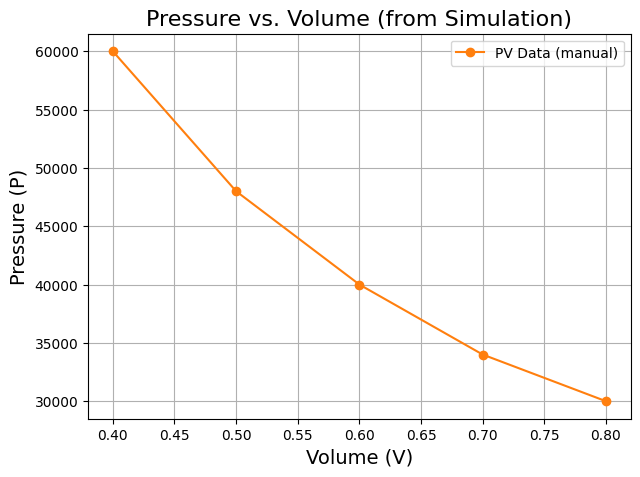

In [4]:
# Option 2: Paste your PV data as a Python list and plot
import matplotlib.pyplot as plt

# Paste your data here as a list of (V, P) tuples
pv_data = [
    # Example: (volume, pressure)
    (0.8, 30000),
    (0.7, 34000),
    (0.6, 40000),
    (0.5, 48000),
    (0.4, 60000),
    # ...add your own data from the simulation
]

if pv_data:
    v_vals, p_vals = zip(*pv_data)
    plt.figure(figsize=(7,5))
    plt.plot(v_vals, p_vals, 'o-', color='tab:orange', label='PV Data (manual)')
    plt.xlabel('Volume (V)', fontsize=14)
    plt.ylabel('Pressure (P)', fontsize=14)
    plt.title('Pressure vs. Volume (from Simulation)', fontsize=16)
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print('Paste your PV data as a list of (V, P) tuples to plot.')

<font color="#99ffcc" size=6><b>   Oscillation and Thermodynamics Simulator </b></font>
***

Author: Cristián Allendes Flores

Interactive educational notebook developed in Python for teaching and visualizing classical physics concepts.

## Contents

This notebook currently includes two main simulation modules:

### 1. Oscillations

Interactive simulations of:

* Simple Harmonic Motion (SHM)
* Damped Oscillations
* Forced Oscillations
* Resonance phenomena
* Superposition of waves

Additional studies include the effect of varying the damping coefficient (γ) on the amplitude decay of oscillatory systems.

### 2. Thermodynamics

Interactive ideal gas simulator featuring:

* Free mode
* Isochoric processes (constant volume)
* Isobaric processes (constant pressure)
* Isothermal processes (constant temperature)
* Adiabatic processes

The simulator includes:

* Particle-based visualization
* Movable piston
* Real-time pressure calculation
* P–V diagram generation
* State logging and cycle visualization

## Physical Models

### Oscillations

The notebook explores solutions of differential equations describing damped and driven harmonic oscillators, including the role of the damping coefficient γ.

### Thermodynamics

The thermodynamic module is based on:

PV = NkT

and includes:

* Isothermal: PV = constant
* Isochoric: P/T = constant
* Isobaric: V/T = constant
* Adiabatic: PV^γ = constant

with γ = 5/3 for a monoatomic ideal gas.

## Requirements

* Python 3.x
* NumPy
* Matplotlib
* Pygame
* Jupyter Notebook

## Author

Cristián Allendes Flores

Universidad Andrés Bello

2026


In [3]:
# ================================
# CONSTANTS & LAYOUT
# ================================
WIDTH, HEIGHT = 1200, 680
CONTROL_PANEL_W = 300
CHAMBER_W = 380
CHAMBER_H = 450

CHAMBER_X = CONTROL_PANEL_W + 40
CHAMBER_Y = 120

GRAPH_X = CHAMBER_X + CHAMBER_W + 50
GRAPH_Y = CHAMBER_Y
GRAPH_W = 380
GRAPH_H = 450

PISTON_MIN = 0.2
PISTON_MAX = 1.0

# Colors (Dark Mode Layout)
BLACK = (12, 12, 16)
DARK_GRAY = (30, 30, 38)
MID_GRAY = (55, 55, 65)
LIGHT_GRAY = (190, 190, 200)
WHITE = (240, 240, 245)
BLUE = (70, 140, 240)
RED = (225, 75, 75)
GREEN = (70, 210, 95)
ORANGE = (235, 135, 45)
GOLD = (255, 215, 0)
# ================================
# INITIAL STATE & CONTROLS
# ================================
N = 80
T = 300
VOLUME_FACTOR = 1.0  # 1.0 = Max Piston Box Volume
PARTICLE_RADIUS = 5

GAMMA = 5/3  # Adiabatic index for monoatomic ideal gas
adiabatic_constant = T * (VOLUME_FACTOR ** (GAMMA - 1))

# Modes: 'FREE', 'ISOCHORIC', 'ISOBARIC', 'ISOTHERMAL'
current_mode = 'FREE'
datapoints = []  # Stores (V, P, color) to draw the distinct path colors

# Target Pressure for Isobaric Constraints
target_pressure = (N * T) / VOLUME_FACTOR

# ================================
# PARTICLES CORE LOGIC
# ================================
def speed_from_temperature(temp):
    return math.sqrt(temp) * 0.35

def reset_particles():
    global particles
    particles = []
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    for _ in range(N):
        x = random.uniform(CHAMBER_X + PARTICLE_RADIUS, CHAMBER_X + CHAMBER_W - PARTICLE_RADIUS)
        y = random.uniform(CHAMBER_Y + PARTICLE_RADIUS, CHAMBER_Y + piston_h - PARTICLE_RADIUS)
        angle = random.uniform(0, 2 * math.pi)
        speed = speed_from_temperature(T)
        vx = speed * math.cos(angle)
        vy = speed * math.sin(angle)
        particles.append([x, y, vx, vy])

def update_particles():
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    for p in particles:
        p[0] += p[2]
        p[1] += p[3]
        
        # Side Walls
        if p[0] - PARTICLE_RADIUS <= CHAMBER_X:
            p[0] = CHAMBER_X + PARTICLE_RADIUS
            p[2] *= -1
        elif p[0] + PARTICLE_RADIUS >= CHAMBER_X + CHAMBER_W:
            p[0] = CHAMBER_X + CHAMBER_W - PARTICLE_RADIUS
            p[2] *= -1
            
        # Top Wall
        if p[1] - PARTICLE_RADIUS <= CHAMBER_Y:
            p[1] = CHAMBER_Y + PARTICLE_RADIUS
            p[3] *= -1
        # Dynamic Moveable Piston Floor Boundary
        elif p[1] + PARTICLE_RADIUS >= CHAMBER_Y + piston_h:
            p[1] = CHAMBER_Y + piston_h - PARTICLE_RADIUS
            p[3] *= -1

def apply_temperature_change():
    speed = speed_from_temperature(T)
    for p in particles:
        angle = math.atan2(p[3], p[2])
        p[2] = speed * math.cos(angle)
        p[3] = speed * math.sin(angle)

def get_current_pressure():
    return (N * T) / VOLUME_FACTOR

def get_mode_color(mode):
    if mode == 'ISOCHORIC': return BLUE
    if mode == 'ISOBARIC': return ORANGE
    if mode == 'ISOTHERMAL': return GREEN
    if mode == 'ADIABATIC': return GOLD
    return LIGHT_GRAY

# ================================
# UI AND GRAPHICS LAYOUT
# ================================
def draw_text(text, x, y, size=18, color=WHITE):
    font = pygame.font.SysFont("Arial", size)
    img = font.render(text, True, color)
    screen.blit(img, (x, y))

def draw_slider(x, y, w, h, value, min_val, max_val, label, locked=False):
    color = MID_GRAY if not locked else DARK_GRAY
    pygame.draw.rect(screen, color, (x, y + h//2 - 3, w, 6), border_radius=3)

    # Clamp only the visual position of the knob
    # The physical value can still be larger or smaller than the display range
    visual_value = min(max(value, min_val), max_val)

    
    knob_x = int(x + (visual_value - min_val) / (max_val - min_val) * w)
    knob_color = LIGHT_GRAY if locked else RED
    pygame.draw.circle(screen, knob_color, (knob_x, y + h//2), h//2)

    display_label = f"{label}: LOCKED" if locked else f"{label}: {round(value, 2)}"
    draw_text(display_label, x, y - 22, 16, LIGHT_GRAY if not locked else MID_GRAY)

def draw_control_panel():
    pygame.draw.rect(screen, DARK_GRAY, (0, 0, CONTROL_PANEL_W, HEIGHT))
    draw_text("Thermodynamics Lab", 20, 20, 24, WHITE)
    
    global slider_rects, button_rects
    slider_rects = []
    button_rects = []
    
    # Render Sliders with conditional safety locks based on active thermodynamic constraint
    # N Slider (Always open)
    slider_rects.append((30, 90, 220, 20, 'N'))
    draw_slider(30, 90, 220, 20, N, 10, 200, "Particles (N)")
    
    # T Slider (Locked in Isothermal) and Adiabaitc (Locked in Adiabatic)
    is_t_locked = (current_mode == 'ISOTHERMAL' or current_mode == 'ADIABATIC')
    slider_rects.append((30, 150, 220, 20, 'T'))
    draw_slider(30, 150, 220, 20, T, 50, 600, "Temperature (T)", locked=is_t_locked)
    
    # V Slider (Locked in Isochoric)
    is_v_locked = (current_mode == 'ISOCHORIC')
    slider_rects.append((30, 210, 220, 20, 'V'))
    draw_slider(30, 210, 220, 20, VOLUME_FACTOR, PISTON_MIN, PISTON_MAX, "Volume Factor (V)", locked=is_v_locked)
    
    # Mode Buttons Layout
    pygame.draw.line(screen, MID_GRAY, (15, 260), (CONTROL_PANEL_W - 15, 260), 1)
    draw_text("Select Constraints:", 25, 275, 18, WHITE)
    
    modes_list = [
        ('FREE', 'Free Play'), 
        ('ISOCHORIC', 'Isochoric (Const V)'), 
        ('ISOBARIC', 'Isobaric (Const P)'), 
        ('ISOTHERMAL', 'Isothermal (Const T)'),
        ('ADIABATIC', 'Adiabatic (Const Q)')
    ]
    
    b_y = 310
    for mode_id, label in modes_list:
        bg_color = get_mode_color(mode_id) if current_mode == mode_id else MID_GRAY
        txt_color = BLACK if current_mode == mode_id else WHITE
        
        # Draw Button Rect
        b_rect = pygame.Rect(25, b_y, CONTROL_PANEL_W - 50, 30)
        pygame.draw.rect(screen, bg_color, b_rect, border_radius=5)
        
        # Center-ish text inside button area
        draw_text(label, 40, b_y + 5, 15, txt_color)
        button_rects.append((b_rect, mode_id))
        b_y += 40

    # Macro Variables Readouts Box
    pygame.draw.line(screen, MID_GRAY, (15, 525), (CONTROL_PANEL_W - 15, 525), 1)
    P = get_current_pressure()
    draw_text("Live Quantities:", 25, 500, 18, GREEN)
    draw_text(f"Volume (V): {VOLUME_FACTOR:.3f} m³", 30, 530, 16, LIGHT_GRAY)
    draw_text(f"Pressure (P): {P:.1f} kPa", 30, 555, 16, RED)
    draw_text(f"Temperature (T): {int(T)} K", 30, 580, 16, BLUE)
    
    # Quick Commands Reminder Info Box footer
    draw_text("[SPACE]: Log Point   [C]: Reset Graph", 20, 635, 14, LIGHT_GRAY)

def draw_simulation_chamber():
    draw_text("Cylinder Container Space", CHAMBER_X, CHAMBER_Y - 30, 20, WHITE)
    pygame.draw.rect(screen, MID_GRAY, (CHAMBER_X, CHAMBER_Y, CHAMBER_W, CHAMBER_H), 3)
    
    # Movable Piston Head (Closes container boundaries from bottom edge upwards)
    piston_h = int(CHAMBER_H * VOLUME_FACTOR)
    pygame.draw.rect(screen, RED, (CHAMBER_X, CHAMBER_Y + piston_h - 4, CHAMBER_W, 8))
    
    # Simple speed visualization logic bounds
    for p in particles:
        speed = math.hypot(p[2], p[3])
        # Base colors relative to standard system temperature settings
        ratio = min(max((speed - 1) / 8, 0), 1)
        r = int(70 + ratio * 165)
        b = int(240 - ratio * 160)
        pygame.draw.circle(screen, (r, 100, b), (int(p[0]), int(p[1])), PARTICLE_RADIUS)

def draw_pv_graph():
    draw_text("P-V Diagram State Mapping", GRAPH_X, GRAPH_Y - 30, 20, WHITE)
    pygame.draw.rect(screen, DARK_GRAY, (GRAPH_X, GRAPH_Y, GRAPH_W, GRAPH_H))
    pygame.draw.rect(screen, LIGHT_GRAY, (GRAPH_X, GRAPH_Y, GRAPH_W, GRAPH_H), 2)
    
    # Coordinate system frame boundary lines
    pygame.draw.line(screen, WHITE, (GRAPH_X, GRAPH_Y + GRAPH_H), (GRAPH_X + GRAPH_W, GRAPH_Y + GRAPH_H), 2)
    pygame.draw.line(screen, WHITE, (GRAPH_X, GRAPH_Y), (GRAPH_X, GRAPH_Y + GRAPH_H), 2)
    
    draw_text("V (m³)", GRAPH_X + GRAPH_W - 55, GRAPH_Y + GRAPH_H + 10, 15, LIGHT_GRAY)
    draw_text("P (kPa)", GRAPH_X - 60, GRAPH_Y + 5, 15, RED)
    
    # Static Maximum boundaries matching the problem limit calculations
    max_v, min_v = PISTON_MAX, PISTON_MIN
    max_p = (200 * 600) / PISTON_MIN
    
    # Draw any historically saved custom line nodes logged by user
    for pt in datapoints:
        v_val, p_val, pt_color = pt
        gx = GRAPH_X + int(((v_val - min_v) / (max_v - min_v)) * (GRAPH_W - 30)) + 15
        gy = GRAPH_Y + GRAPH_H - int((p_val / max_p) * (GRAPH_H - 30)) - 15
        pygame.draw.circle(screen, pt_color, (gx, gy), 4)

    # Realtime ghost preview node tracker dot line location
    curr_p = get_current_pressure()
    cx = GRAPH_X + int(((VOLUME_FACTOR - min_v) / (max_v - min_v)) * (GRAPH_W - 30)) + 15
    cy = GRAPH_Y + GRAPH_H - int((curr_p / max_p) * (GRAPH_H - 30)) - 15
    if GRAPH_X <= cx <= GRAPH_X + GRAPH_W and GRAPH_Y <= cy <= GRAPH_Y + GRAPH_H:
        pygame.draw.circle(screen, WHITE, (cx, cy), 5, 1)

# ================================
# MAIN PROGRAM INITIALIZATION
# ================================
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Thermodynamic Cycle Simulator")
clock = pygame.time.Clock()

reset_particles()
running = True
dragging = None

while running:
    clock.tick(60)
    
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
            
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_SPACE:
                # Capture and log coordinate colorcoded by current mode
                color = get_mode_color(current_mode)
                if current_mode == 'FREE': color = WHITE
                datapoints.append((VOLUME_FACTOR, get_current_pressure(), color))
            elif event.key == pygame.K_c:
                datapoints.clear()
                
        elif event.type == pygame.MOUSEBUTTONDOWN:
            mx, my = event.pos
            
            # Check Mode Buttons Selection clicks first
            for rect, mode_id in button_rects:
                if rect.collidepoint(mx, my):
                    current_mode = mode_id
                    target_pressure = get_current_pressure() # Lock initial baseline target frame
                    
            # Check Sliders Handle Clicks
            for sx, sy, sw, sh, label in slider_rects:
                if sx <= mx <= sx+sw and sy <= my <= sy+sh:
                    # Enforce variable locks based on mode constraints
                    if label == 'T' and current_mode == 'ISOTHERMAL': continue
                    if label == 'V' and current_mode == 'ISOCHORIC': continue
                    if label == 'T' and current_mode == ['ISOTHERMAL', 'ADIABATIC']: continue
                    dragging = label
                    
        elif event.type == pygame.MOUSEBUTTONUP:
            dragging = None
            
        elif event.type == pygame.MOUSEMOTION and dragging:
            mx, my = event.pos
            for sx, sy, sw, sh, label in slider_rects:
                if label == dragging:
                    rel = min(max((mx - sx) / sw, 0), 1)
                    
                    if label == 'N':
                        N = int(10 + rel * (200 - 10))
                        reset_particles()
                        if current_mode == 'ISOBARIC':
                            # Compensate Volume to keep P constant: V = N*T / P
                            VOLUME_FACTOR = min(max((N * T) / target_pressure, PISTON_MIN), PISTON_MAX)
                        
                    elif label == 'T':
                        T = int(50 + rel * (600 - 50))
                        apply_temperature_change()
                        
                        # Apply Constraints dependent reactions
                        if current_mode == 'ISOBARIC':
                            # V must change proportionally to T to preserve fixed baseline target Pressure
                            VOLUME_FACTOR = min(max((N * T) / target_pressure, PISTON_MIN), PISTON_MAX)
                            reset_particles()
                            
                    elif label == 'V':
                        VOLUME_FACTOR = PISTON_MIN + rel * (PISTON_MAX - PISTON_MIN)
                        # reset_particles()
                        
                        # Apply Constraints dependent reactions
                        if current_mode == 'ISOTHERMAL':
                            # Internal pressure naturally recalculates implicitly via global rendering updates
                            pass
                        elif current_mode == 'ADIABATIC':
                            T = int(adiabatic_constant / (VOLUME_FACTOR ** (GAMMA - 1)))
                            apply_temperature_change()
                            pass
                        elif current_mode == 'ISOBARIC':
                            # Update target baseline pressure tracker anchor
                            target_pressure = get_current_pressure()
                        reset_particles()

    update_particles()
    screen.fill(BLACK)
    
    draw_control_panel()
    draw_simulation_chamber()
    draw_pv_graph()
    
    pygame.display.flip()

pygame.quit()